# Práctica 5 — Análisis de Componentes Principales (ACP) aplicado a
# Ventriculografía Radioisotópica en Equilibrio (VRIE)

**Ingeniería Biomédica**

Análisis de estudios dinámicos de cardiología nuclear mediante Análisis de
Componentes Principales (ACP / PCA), con el fin de extraer los principales
patrones espaciales y temporales de la actividad ventricular.

## 1. Introducción

La Ventriculografía Radioisotópica en Equilibrio (VRIE) es una técnica de
cardiología nuclear que permite evaluar de forma no invasiva la función
ventricular. Tras marcar los eritrocitos del paciente con Tecnecio-99m, una
gammacámara adquiere una serie de imágenes sincronizadas con el
electrocardiograma, que representan distintos instantes del ciclo cardíaco
(típicamente 15 a 16 cuadros por ciclo).

Cada estudio resultante es entonces una **serie temporal de imágenes**: para
cada píxel de la imagen se cuenta con una curva de actividad-tiempo (CAT) que
describe cómo cambia la cantidad de radiotrazador detectada (y, por lo
tanto, el volumen sanguíneo aproximado) a lo largo del ciclo cardíaco.

El Análisis de Componentes Principales (ACP) permite resumir esta
información redundante en un pequeño número de **patrones espacio-temporales**
(llamados factores o componentes), cada uno compuesto por:

- Una **imagen factorial** $F_i$ (patrón espacial, de 64×64 píxeles).
- Un **eigenvector temporal** $q_i$ (patrón temporal, de 15 valores, uno por
  cuadro).

Este enfoque —el Análisis de Factores de Estructuras Dinámicas— es el mismo
descrito en la presentación teórica de la práctica (*AFED.pdf*, diapositivas
9 a 13), donde se ilustra cómo los primeros factores concentran la mayor
parte de la variabilidad del estudio y cómo su comparación entre sujetos
puede revelar diferencias en los patrones de contracción ventricular.

## 2. Objetivo

Aplicar el Análisis de Componentes Principales a estudios dinámicos de
Ventriculografía Radioisotópica en Equilibrio para obtener los principales
patrones espaciales y temporales de la actividad ventricular, analizar la
distribución de los eigenvalores y comparar de manera **descriptiva** los
estudios pertenecientes a los grupos **N** y **P**.

> **Nota sobre los grupos N y P.** Los ocho archivos disponibles están
> etiquetados con los prefijos `N` (`N11`, `N12`, `N14`, `N23`) y `P`
> (`P11`, `P12`, `P13`, `P14`). No se cuenta con metadatos clínicos que
> confirmen el significado exacto de estas etiquetas ni el diagnóstico de
> cada sujeto. Por lo tanto, en este notebook se habla únicamente de
> **grupo N** y **grupo P**, sin asumir que "N" significa necesariamente
> "normal" ni que "P" corresponde a una patología específica (por ejemplo,
> bloqueo de rama izquierda o hipertensión arterial pulmonar). Cualquier
> diferencia encontrada entre ambos grupos se reporta como una observación
> exploratoria, no como una conclusión clínica.

## 3. Fundamento teórico

### 3.1 De la imagen dinámica a la matriz de datos

Un estudio VRIE es un volumen $I \in \mathbb{R}^{64 \times 64 \times 15}$: 64×64
píxeles por cuadro y 15 cuadros por ciclo cardíaco. Para aplicar ACP,
reorganizamos el volumen en una matriz

$$X \in \mathbb{R}^{4096 \times 15}$$

en la que **cada fila es un píxel** y **cada columna es un cuadro temporal**;
es decir, cada fila de $X$ es la curva de actividad-tiempo (CAT) de un
píxel.

### 3.2 Centrado

Se centra cada columna (cada cuadro) restando su media a lo largo de todos
los píxeles:

$$X_c = X - \bar{X}$$

donde $\bar{X} \in \mathbb{R}^{1 \times 15}$. No se estandariza dividiendo
entre la desviación estándar, ya que las 15 columnas corresponden a la misma
modalidad de adquisición y están expresadas en las mismas unidades
(cuentas).

### 3.3 Matriz de covarianza y eigendescomposición

Se calcula la matriz de covarianza entre cuadros:

$$C = \operatorname{cov}(X_c) \in \mathbb{R}^{15 \times 15}$$

Como $C$ es real y simétrica, su eigendescomposición

$$C q_i = \lambda_i q_i$$

puede resolverse con un algoritmo numéricamente estable para matrices
simétricas (`np.linalg.eigh`), obteniendo 15 eigenvalores $\lambda_i$ y sus
correspondientes eigenvectores $q_i$ (cada uno de 15 elementos), ordenados
de mayor a menor varianza explicada.

### 3.4 Proyección: imágenes factoriales

Las puntuaciones o proyecciones se obtienen con:

$$F = X_c\, Q \in \mathbb{R}^{4096 \times 15}$$

donde $Q$ es la matriz cuyas columnas son los eigenvectores $q_i$. Cada
columna $F_i = F[:, i]$, al reacomodarse como una imagen de 64×64, es la
**imagen factorial** asociada al patrón temporal $q_i$.

> La presentación (AFED.pdf) expresa la relación como $F = Q^T X$, con una
> orientación matricial distinta (píxeles en columnas). En este notebook,
> $X$ tiene los píxeles en las filas y los cuadros en las columnas, por lo
> que la operación equivalente es $F = X_c Q$.

### 3.5 Reconstrucción con $k$ componentes

Con las primeras $k$ componentes es posible reconstruir una aproximación de
los datos originales:

$$\hat{X}_k = F_k\, Q_k^T + \bar{X}$$

Esta reconstrucción es una demostración de **reducción dimensional**: cuanto
mayor es $k$, menor es el error de reconstrucción, hasta ser prácticamente
nulo con las 15 componentes.

### 3.6 Varianza explicada

La proporción de varianza explicada por la componente $i$ es

$$\text{VE}_i = \frac{\lambda_i}{\sum_{j=1}^{15} \lambda_j}$$

y la varianza acumulada de las primeras $k$ componentes es
$\sum_{i=1}^{k} \text{VE}_i$.

## 4. Archivos y estructura de los datos

Los datos se distribuyen en `VRIE_estudios.zip`, que contiene ocho archivos
`.mat`, uno por estudio:

| Archivo | Variable interna | Grupo |
|---|---|---|
| `N11_estudio.mat` | `N11` | N |
| `N12_estudio.mat` | `N12` | N |
| `N14_estudio.mat` | `N14` | N |
| `N23_estudio.mat` | `N23` | N |
| `P11_estudio.mat` | `P11` | P |
| `P12_estudio.mat` | `P12` | P |
| `P13_estudio.mat` | `P13` | P |
| `P14_estudio.mat` | `P14` | P |

Cada arreglo tiene dimensiones `(64, 64, 1, 15)`: 64×64 píxeles, una
dimensión intermedia de tamaño 1 (sin información) y 15 cuadros del ciclo
cardíaco. Esa dimensión singleton se elimina de forma controlada
(`np.squeeze(arreglo, axis=2)`, verificada con `assert`) para obtener un
volumen `(64, 64, 15)`.

El ZIP se extrae automáticamente a `VRIE_estudios/` si esa carpeta o sus
archivos no existen todavía; si ya existen, no se vuelve a extraer.

## 5. Importación de bibliotecas

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import Markdown, display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)

# Rutas relativas a la carpeta donde se encuentra este notebook (Downloads),
# donde también residen el ZIP de datos y los notebooks de referencia.
DIR_BASE = Path.cwd()
RUTA_ZIP = DIR_BASE / "VRIE_estudios.zip"
DIR_EXTRACCION = DIR_BASE / "VRIE_estudios"

IDENTIFICADORES = ["N11", "N12", "N14", "N23", "P11", "P12", "P13", "P14"]

print(f"Directorio base:        {DIR_BASE}")
print(f"Archivo ZIP esperado:   {RUTA_ZIP}  (existe: {RUTA_ZIP.exists()})")
print(f"Carpeta de extracción:  {DIR_EXTRACCION}  (existe: {DIR_EXTRACCION.exists()})")

Directorio base:        c:\Users\PC\Downloads
Archivo ZIP esperado:   c:\Users\PC\Downloads\VRIE_estudios.zip  (existe: True)
Carpeta de extracción:  c:\Users\PC\Downloads\VRIE_estudios  (existe: True)


## 6. Extracción y carga de los estudios

La función `cargar_estudios` extrae el ZIP únicamente si hace falta, carga
los ocho archivos `.mat`, detecta automáticamente la variable válida dentro
de cada archivo (ignorando las claves auxiliares `__header__`,
`__version__` y `__globals__` que agrega `scipy.io.loadmat`), verifica que
el nombre de la variable coincida con el identificador esperado y valida
las dimensiones antes y después de eliminar la dimensión singleton.

In [2]:
def cargar_estudios(ruta_zip, ruta_extraccion, identificadores):
    """Extrae (si hace falta) el ZIP de estudios VRIE y carga cada volumen.

    Parámetros
    ----------
    ruta_zip : Path
        Ruta al archivo VRIE_estudios.zip.
    ruta_extraccion : Path
        Carpeta donde están o se extraerán los archivos .mat.
    identificadores : list[str]
        Identificadores de estudio, p. ej. ["N11", "N12", ...].

    Regresa
    -------
    dict[str, np.ndarray]
        Diccionario {identificador: volumen} con volumen de forma (64, 64, 15).
    """
    ruta_extraccion.mkdir(parents=True, exist_ok=True)

    archivos_esperados = [f"{ident}_estudio.mat" for ident in identificadores]
    faltan = [a for a in archivos_esperados if not (ruta_extraccion / a).exists()]

    if faltan:
        if not ruta_zip.exists():
            raise FileNotFoundError(
                f"No se encontró '{ruta_zip}' y faltan los archivos {faltan}."
            )
        with zipfile.ZipFile(ruta_zip) as z:
            z.extractall(ruta_extraccion)
        print(f"ZIP extraído en: {ruta_extraccion}")
    else:
        print("Los archivos .mat ya estaban extraídos; no fue necesario descomprimir.")

    estudios = {}
    for ident in identificadores:
        ruta_mat = ruta_extraccion / f"{ident}_estudio.mat"
        contenido = sio.loadmat(ruta_mat)

        claves_validas = [k for k in contenido.keys() if not k.startswith("__")]
        if ident not in claves_validas:
            raise KeyError(
                f"Se esperaba la variable '{ident}' en {ruta_mat}, "
                f"pero se encontraron las claves {claves_validas}."
            )

        arreglo = contenido[ident]
        if arreglo.shape != (64, 64, 1, 15):
            raise ValueError(
                f"Dimensiones inesperadas en {ident}: {arreglo.shape}; "
                "se esperaba (64, 64, 1, 15)."
            )

        volumen = np.squeeze(arreglo, axis=2)
        assert volumen.shape == (64, 64, 15), (
            f"Error al eliminar la dimensión singleton en {ident}: "
            f"forma resultante {volumen.shape}"
        )
        estudios[ident] = volumen

    return estudios


estudios = cargar_estudios(RUTA_ZIP, DIR_EXTRACCION, IDENTIFICADORES)

print(f"\nEstudios cargados: {list(estudios.keys())}")
for ident, vol in estudios.items():
    print(f"  {ident}: forma = {vol.shape}, dtype = {vol.dtype}, "
          f"grupo = {ident[0]}")

Los archivos .mat ya estaban extraídos; no fue necesario descomprimir.

Estudios cargados: ['N11', 'N12', 'N14', 'N23', 'P11', 'P12', 'P13', 'P14']
  N11: forma = (64, 64, 15), dtype = float64, grupo = N
  N12: forma = (64, 64, 15), dtype = float64, grupo = N
  N14: forma = (64, 64, 15), dtype = float64, grupo = N
  N23: forma = (64, 64, 15), dtype = float64, grupo = N
  P11: forma = (64, 64, 15), dtype = float64, grupo = P
  P12: forma = (64, 64, 15), dtype = float64, grupo = P
  P13: forma = (64, 64, 15), dtype = float64, grupo = P
  P14: forma = (64, 64, 15), dtype = float64, grupo = P


## 7. Visualización de las secuencias originales

`visualizar_secuencia` muestra los 15 cuadros originales de un estudio en
una cuadrícula de 3×5, numerados del 1 al 15 (no del 0 al 14), con una
barra de color compartida que indica la escala de cuentas.

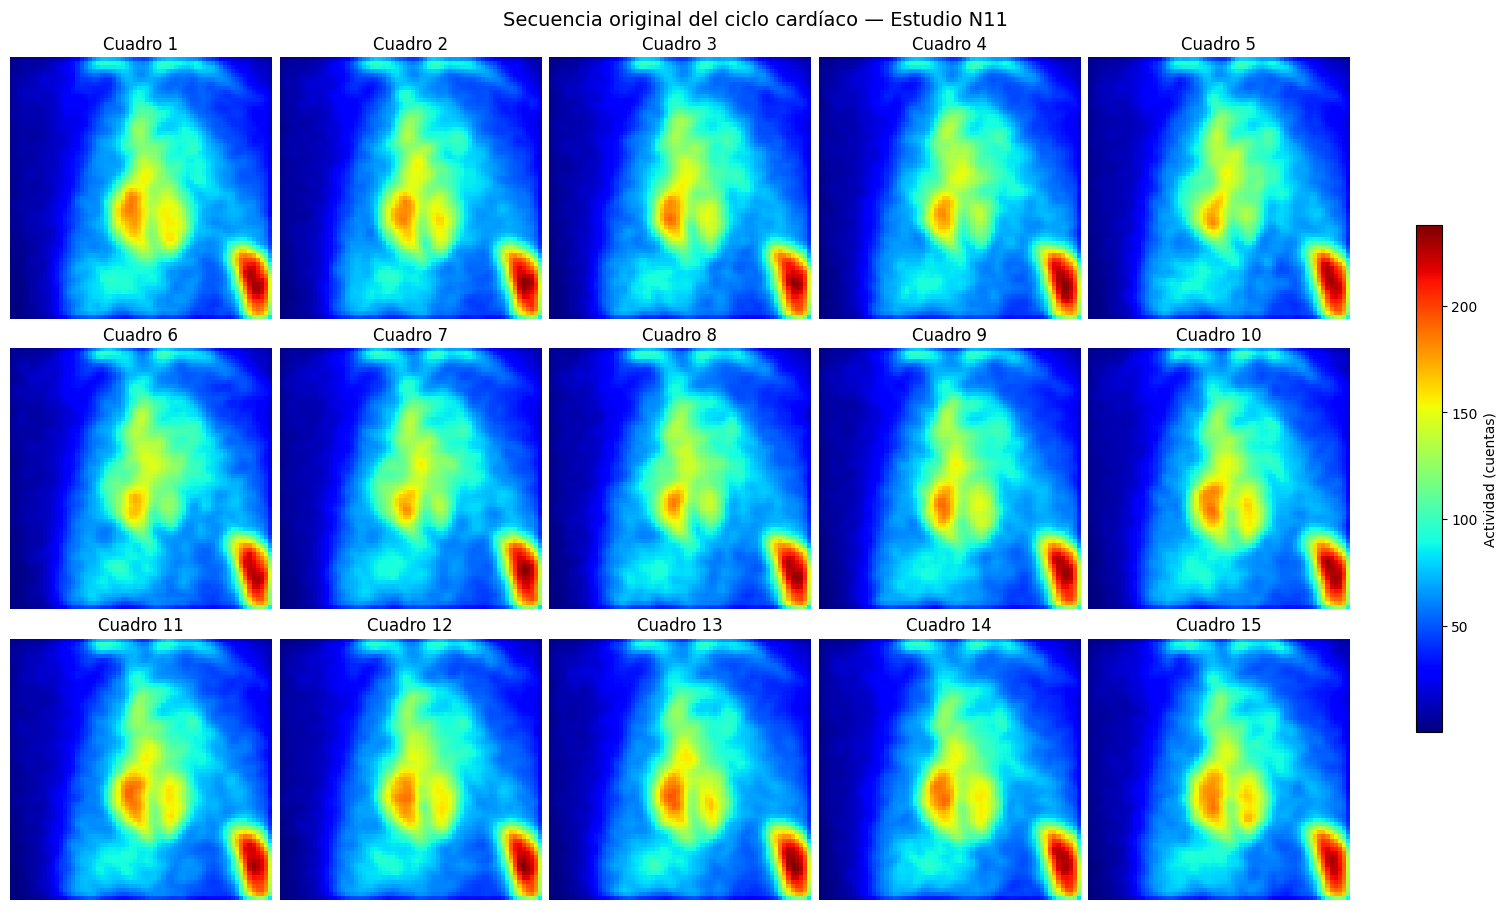

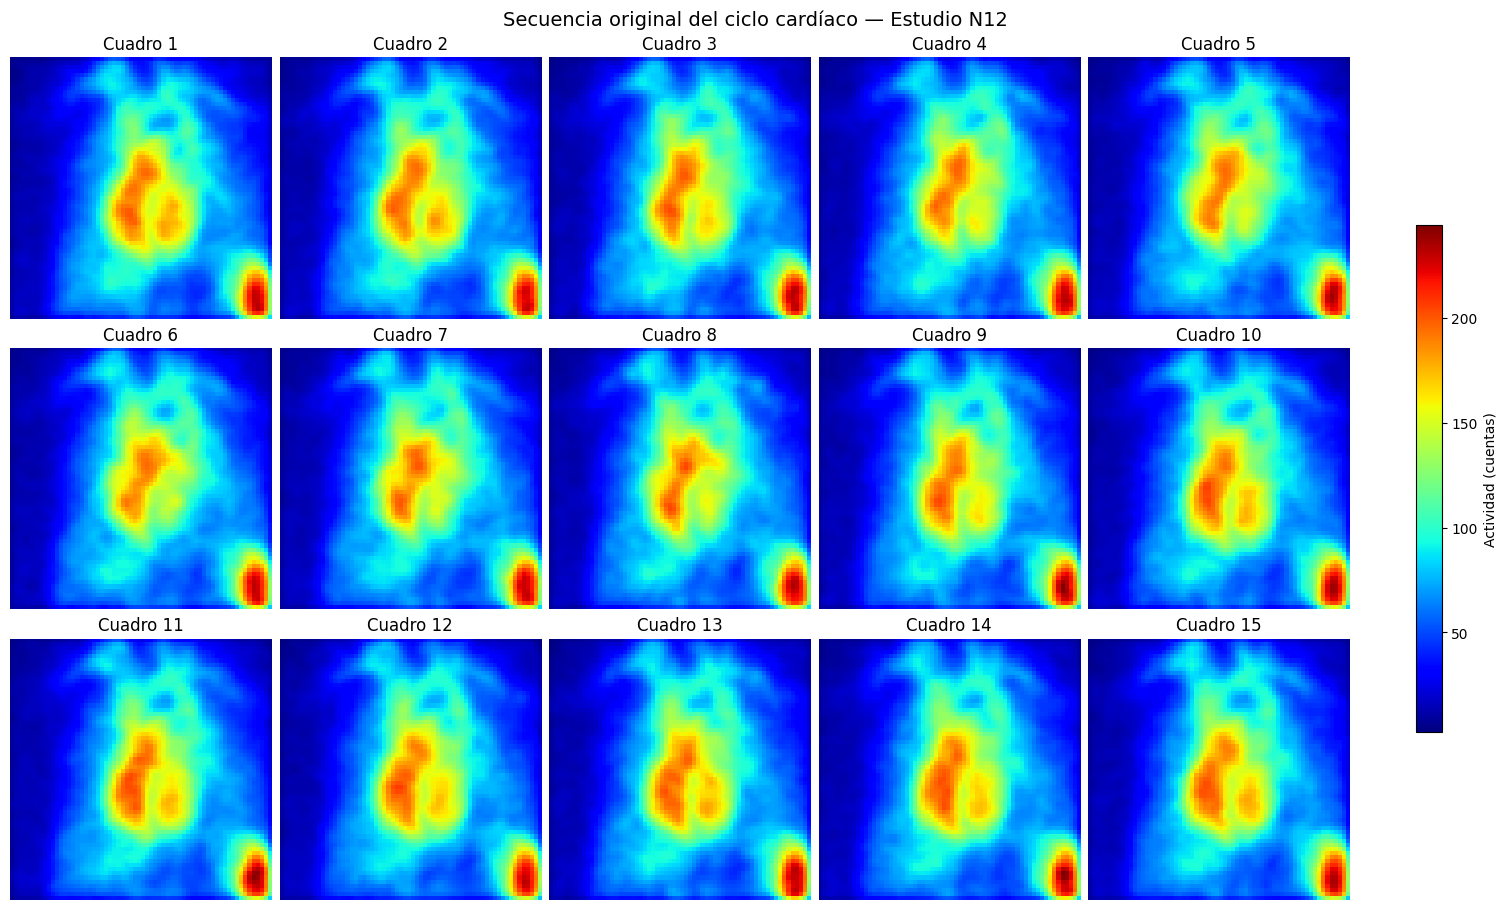

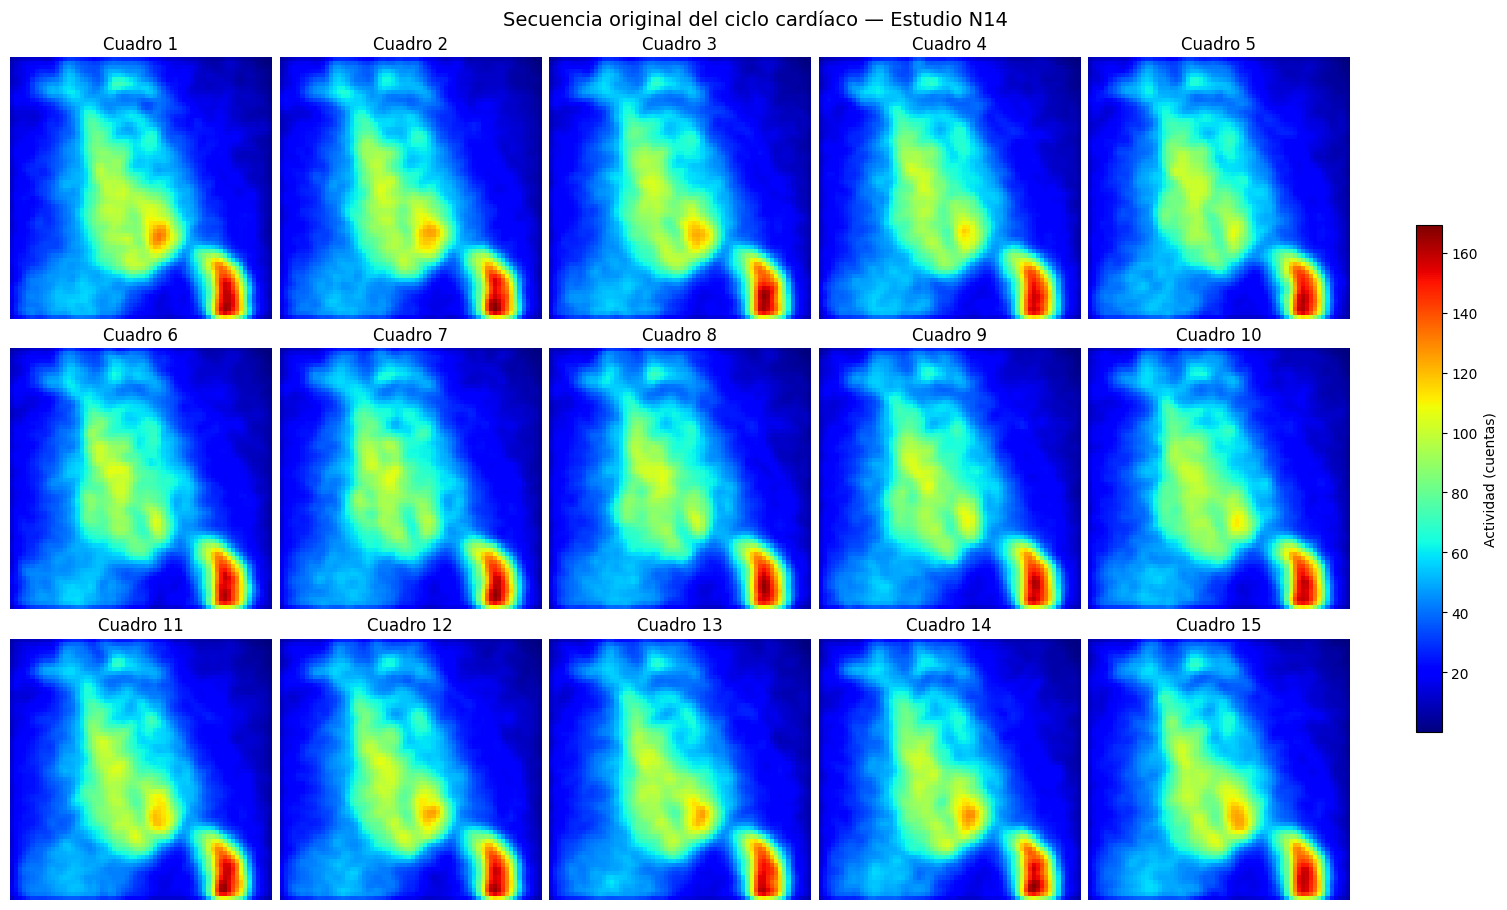

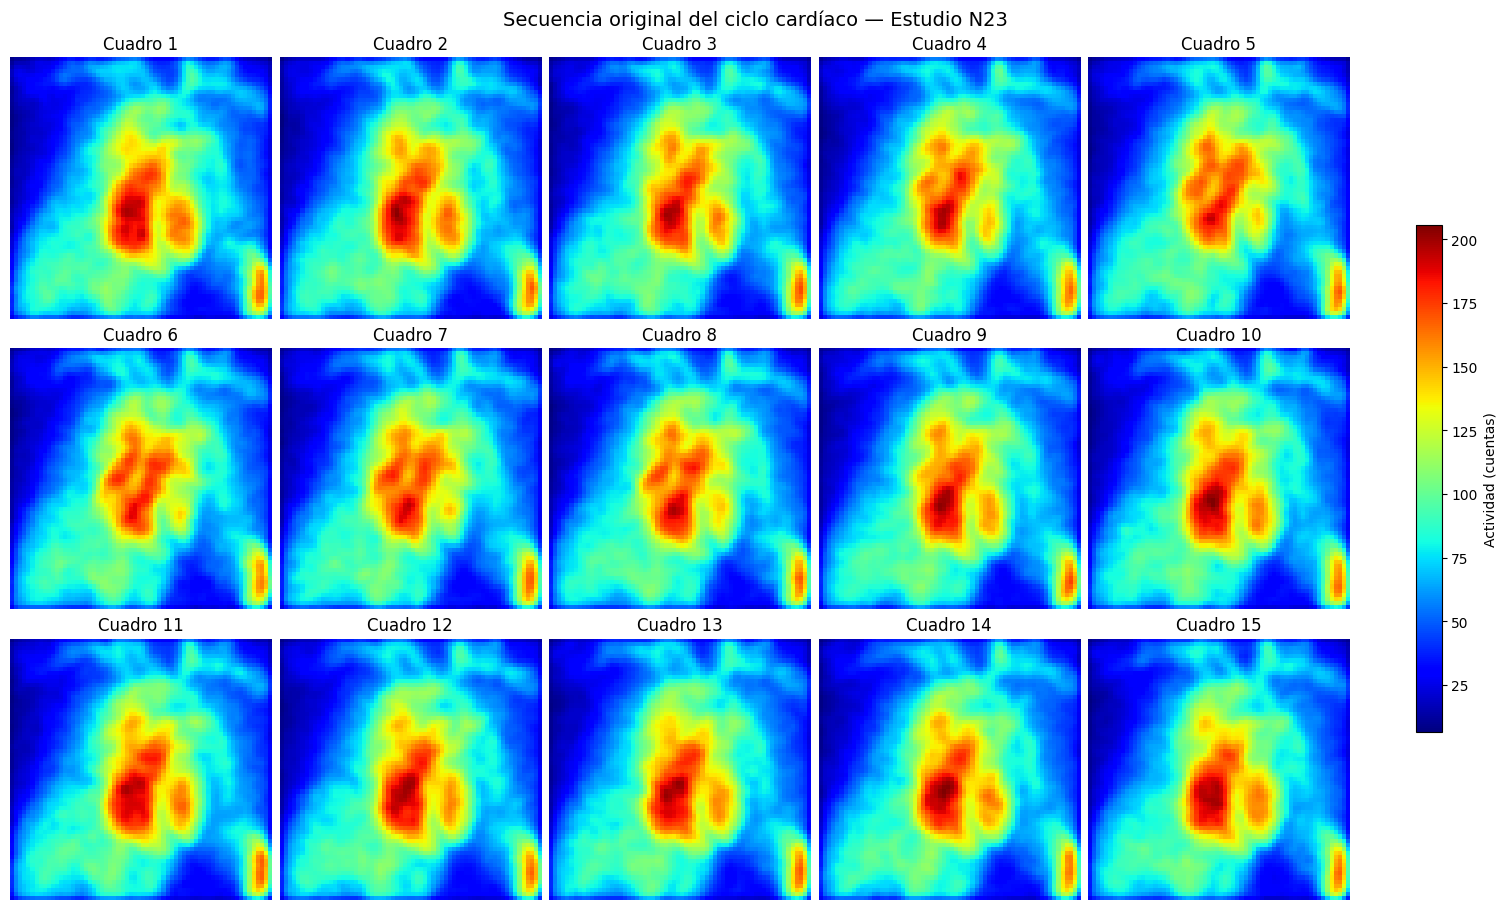

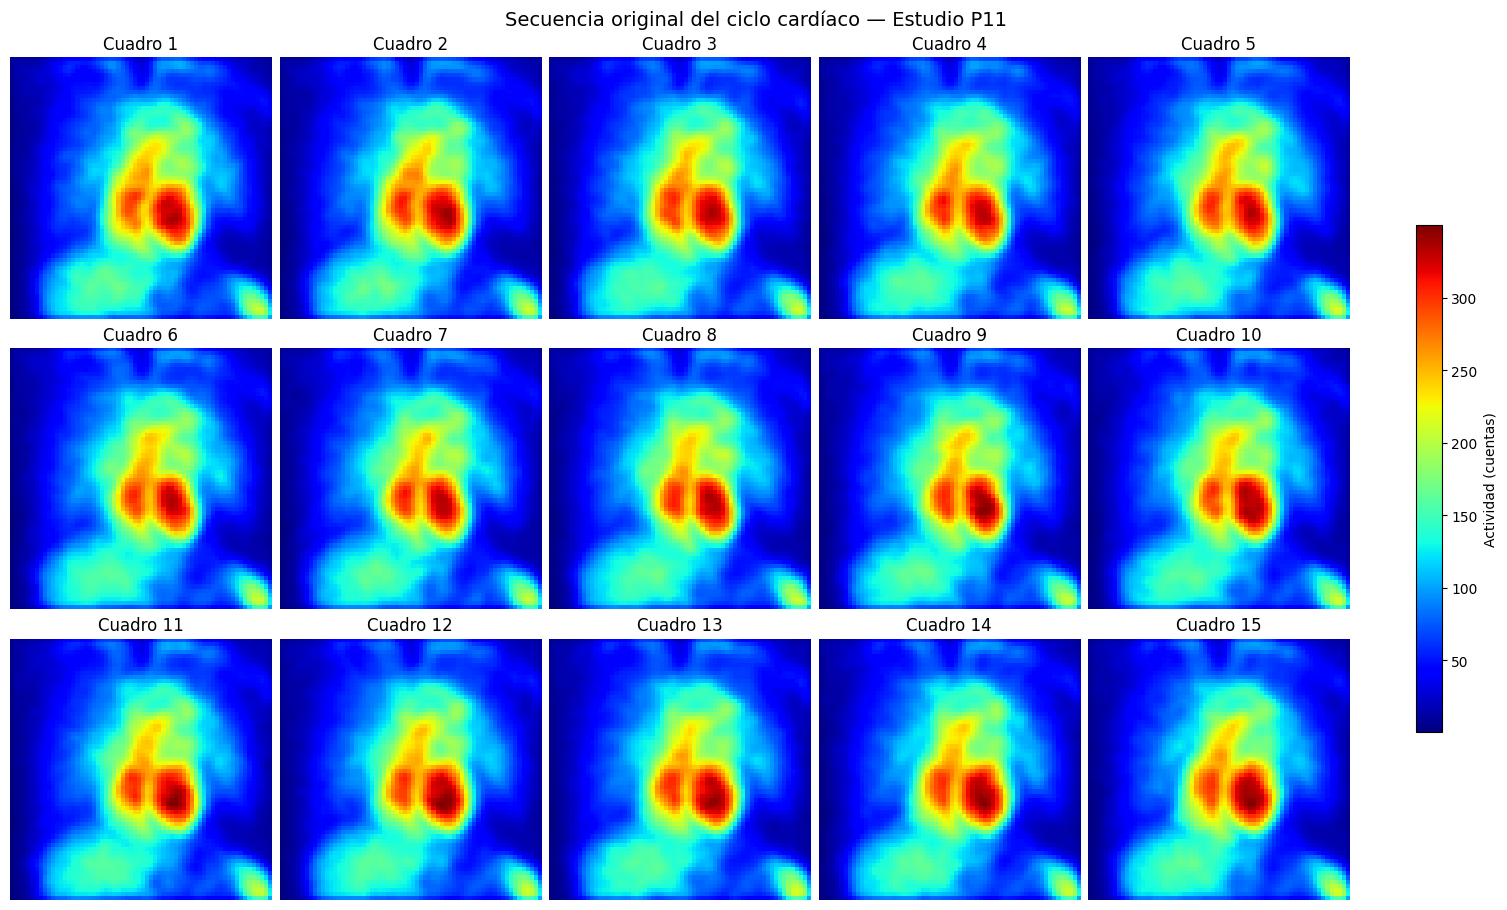

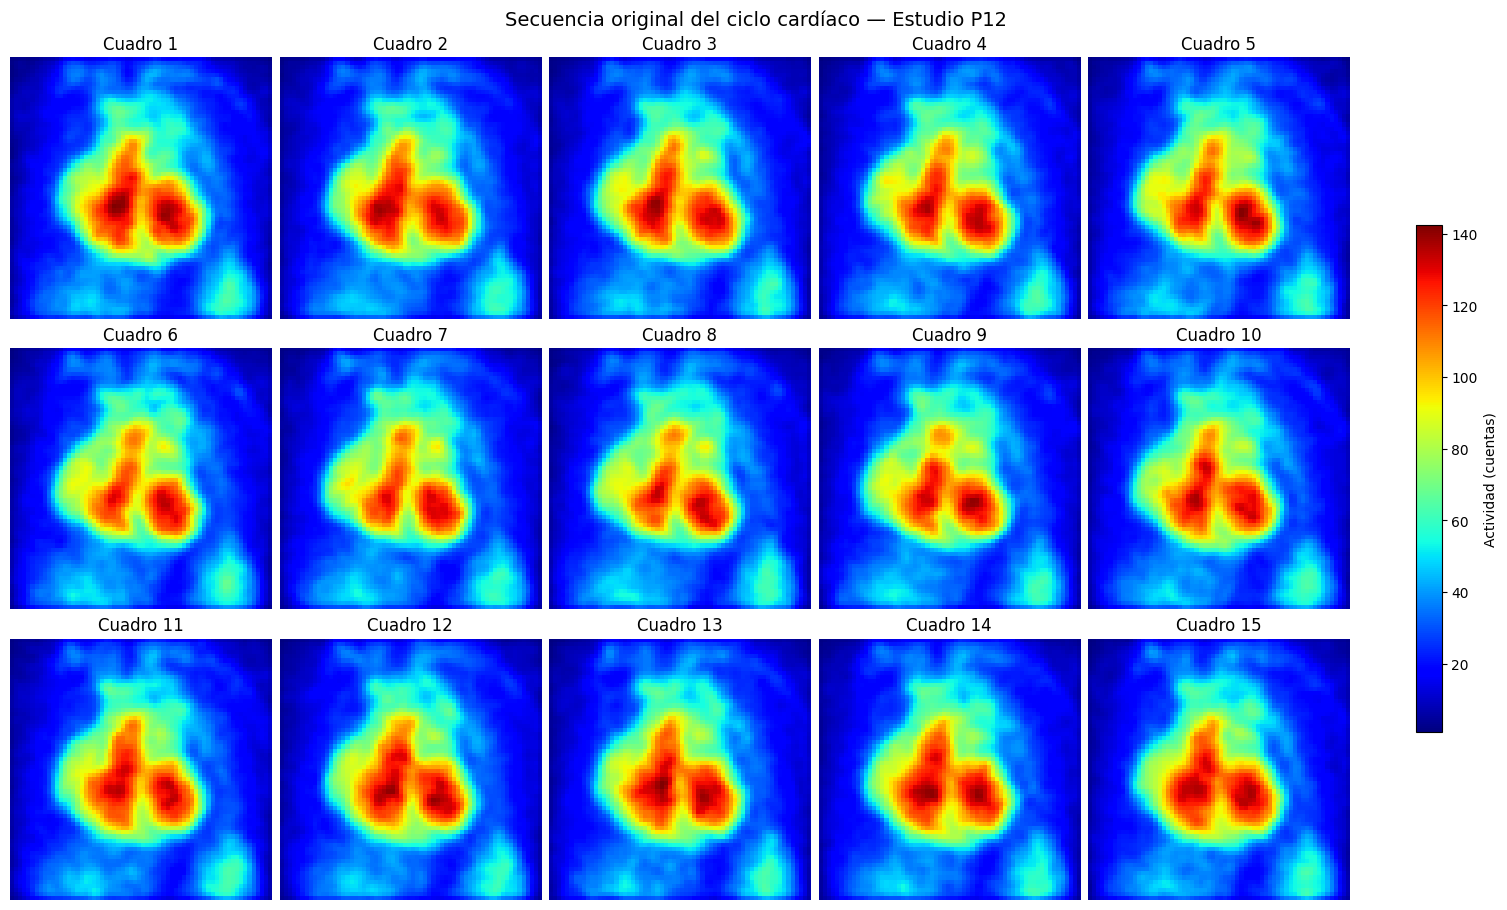

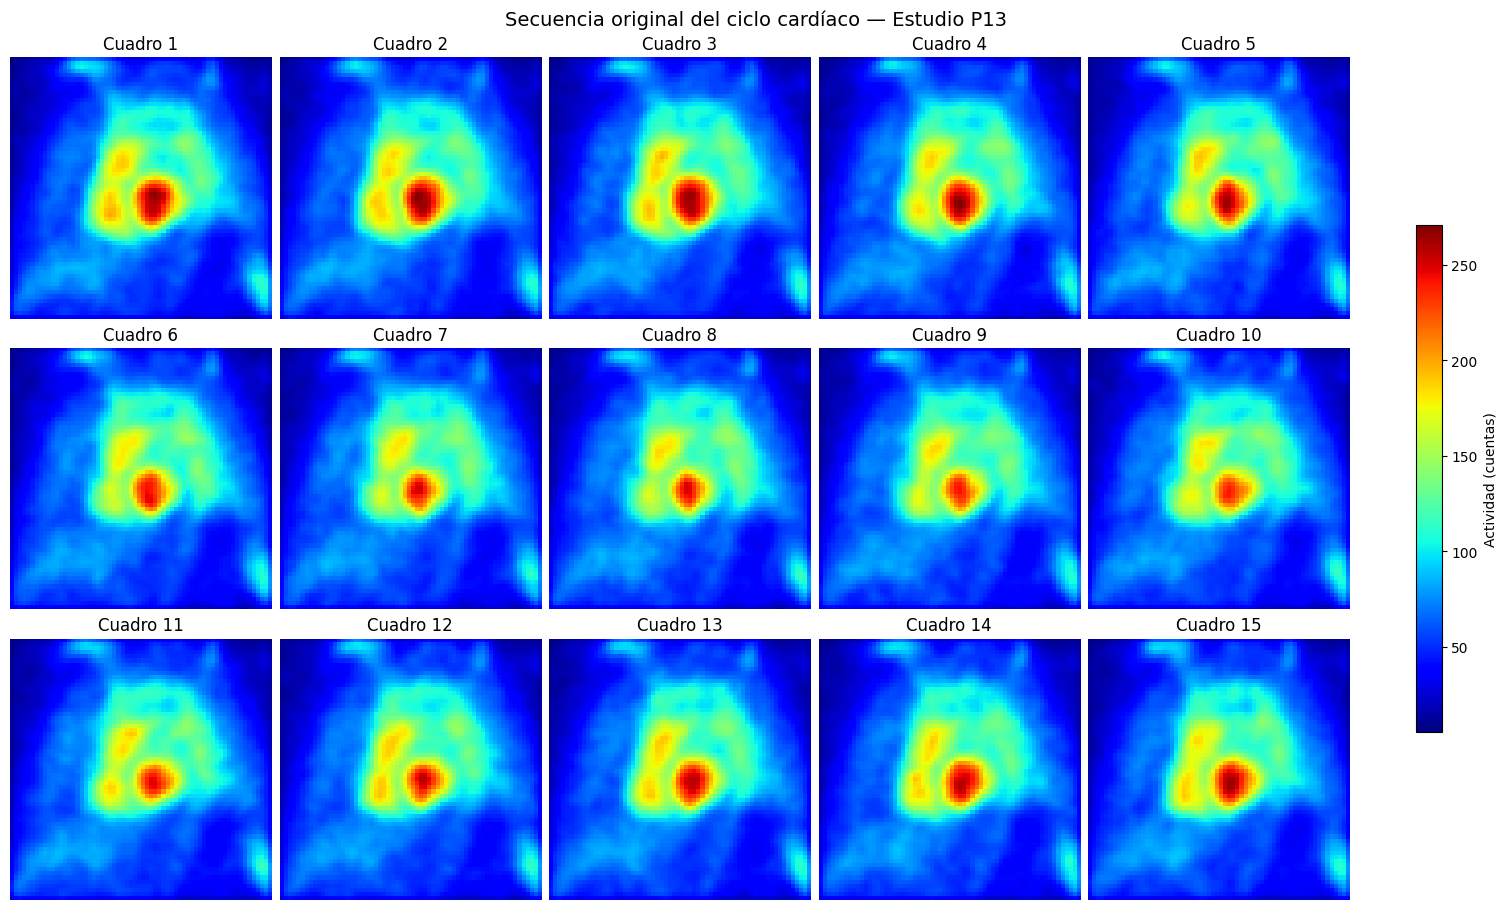

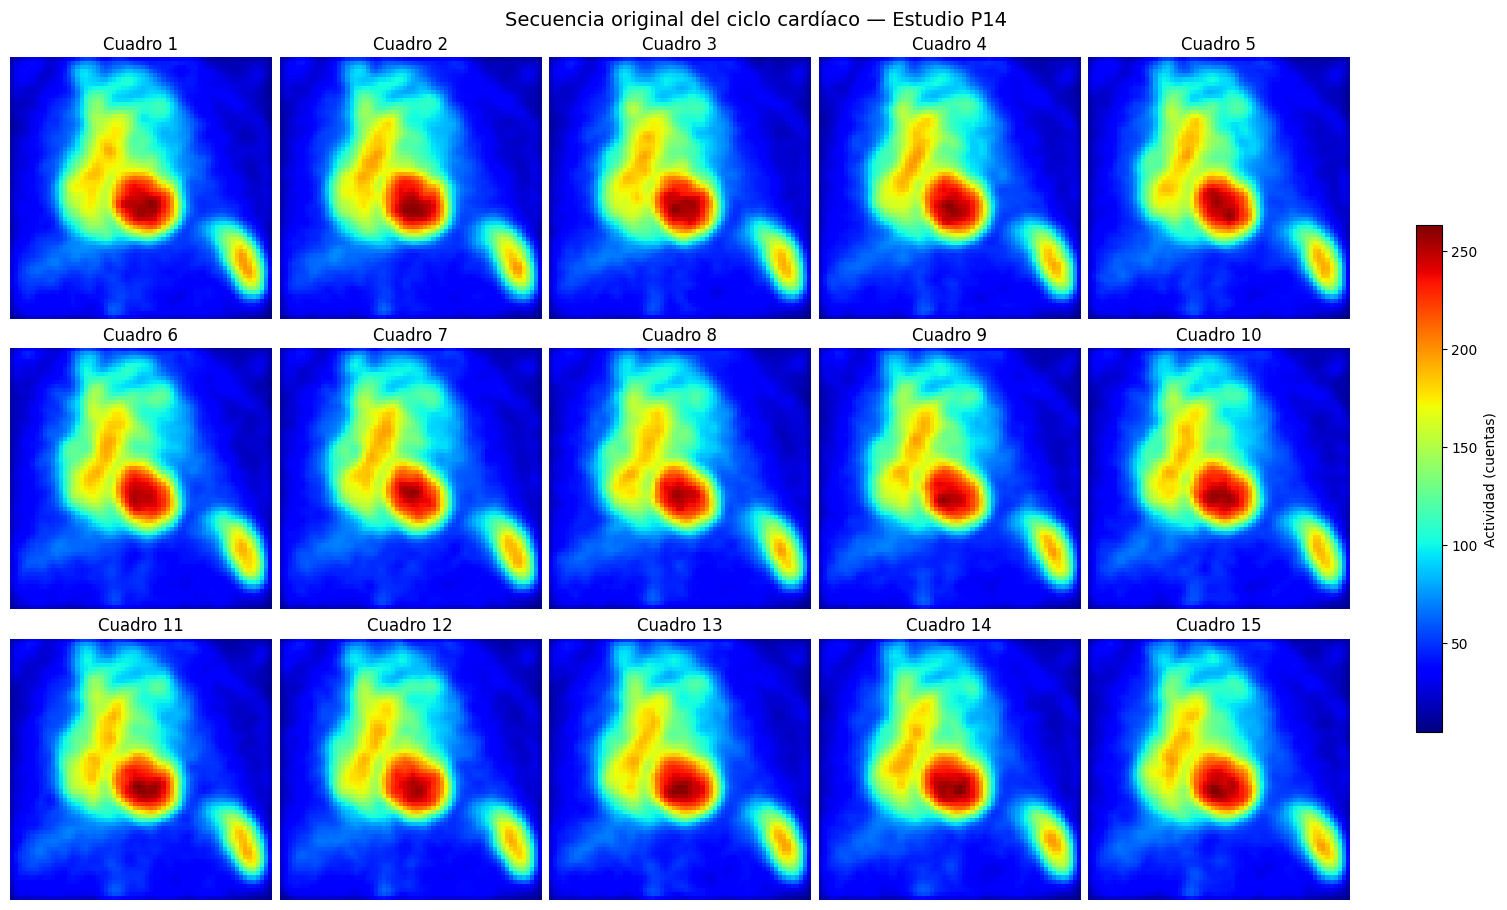

In [3]:
def visualizar_secuencia(volumen, nombre):
    """Muestra los 15 cuadros originales de un estudio en una cuadrícula 3x5."""
    fig, axs = plt.subplots(3, 5, figsize=(15, 9), constrained_layout=True)
    vmin, vmax = volumen.min(), volumen.max()
    for i, ax in enumerate(axs.flat):
        im = ax.imshow(volumen[:, :, i], cmap="jet", vmin=vmin, vmax=vmax)
        ax.set_title(f"Cuadro {i + 1}")
        ax.axis("off")
    fig.suptitle(f"Secuencia original del ciclo cardíaco — Estudio {nombre}", fontsize=14)
    fig.colorbar(im, ax=axs, shrink=0.6, label="Actividad (cuentas)")
    plt.show()
    plt.close(fig)


for ident, volumen in estudios.items():
    visualizar_secuencia(volumen, ident)

## 8. Preparación de la matriz de curvas actividad-tiempo

Cada volumen `(64, 64, 15)` se reorganiza en una matriz
$X \in \mathbb{R}^{4096 \times 15}$ mediante `volumen.reshape(64 * 64, 15)`.
Cada fila de $X$ es entonces la curva de actividad-tiempo de un píxel a lo
largo de los 15 cuadros. Se ilustra el procedimiento con el estudio `N11`
antes de aplicarlo sistemáticamente a los ocho estudios en la siguiente
sección.

In [4]:
volumen_ejemplo = estudios["N11"]
X_ejemplo = volumen_ejemplo.reshape(64 * 64, 15)

assert X_ejemplo.shape == (4096, 15)

print(f"Volumen original:         {volumen_ejemplo.shape}")
print(f"Matriz de CAT (X):        {X_ejemplo.shape}")
print(f"CAT del píxel central (fila 2080), primeros 5 cuadros: "
      f"{X_ejemplo[2080, :5]}")

Volumen original:         (64, 64, 15)
Matriz de CAT (X):        (4096, 15)
CAT del píxel central (fila 2080), primeros 5 cuadros: [151.2313 147.7059 154.8567 138.7742 147.3184]


## 9. Implementación manual del ACP

`calcular_acp_vrie` implementa el procedimiento completo descrito en la
sección de fundamento teórico:

1. Construye $X$ a partir del volumen.
2. Centra $X$ por columnas (por cuadro).
3. Calcula la matriz de covarianza $C$.
4. Obtiene eigenvalores y eigenvectores con `np.linalg.eigh` (apropiado para
   matrices simétricas) y los ordena de mayor a menor varianza.
5. Aplica una convención determinista de signo (ver más abajo).
6. Calcula las proyecciones $F$.
7. Calcula la varianza explicada y acumulada.
8. Verifica, mediante `assert`, todas las propiedades numéricas esperadas
   (dimensiones, simetría, ortonormalidad, orden de eigenvalores,
   normalización de la varianza y reconstrucción exacta con las 15
   componentes).

### Ambigüedad del signo de los componentes

El signo de un eigenvector es arbitrario: $q_i$ y $-q_i$ representan el
mismo componente si también se invierte el signo de $F_i$. Para que las
gráficas sean reproducibles y comparables entre estudios, se aplica la
siguiente convención: en cada eigenvector se localiza el elemento de mayor
valor absoluto; si ese elemento es negativo, se invierte el signo del
eigenvector **y** de su imagen factorial asociada. Esta convención **no
cambia la información del ACP**, solamente fija una orientación visual
reproducible.

In [5]:
def calcular_acp_vrie(volumen, nombre):
    """Aplica el Análisis de Componentes Principales a un estudio VRIE.

    Parámetros
    ----------
    volumen : np.ndarray
        Volumen del estudio, de forma (64, 64, 15).
    nombre : str
        Identificador del estudio (p. ej. "N11").

    Regresa
    -------
    dict
        Diccionario con la matriz de datos, la descomposición y las
        métricas de varianza explicada.
    """
    n_filas, n_columnas, n_cuadros = volumen.shape
    X = volumen.reshape(n_filas * n_columnas, n_cuadros)
    assert X.shape == (4096, 15), f"{nombre}: forma inesperada de X: {X.shape}"

    # 1. Centrado por columna (por cuadro), sin estandarizar
    media = np.mean(X, axis=0, keepdims=True)
    assert media.shape == (1, 15)
    Xc = X - media

    # 2. Matriz de covarianza entre cuadros
    C = np.cov(Xc, rowvar=False)
    assert C.shape == (15, 15)
    assert np.allclose(C, C.T), f"{nombre}: la covarianza no es simétrica"

    # 3. Eigendescomposición (C es simétrica -> eigh)
    eigenvalores, Q = np.linalg.eigh(C)

    # 4. Orden descendente de varianza
    orden = np.argsort(eigenvalores)[::-1]
    eigenvalores = eigenvalores[orden]
    Q = Q[:, orden].copy()

    # Tolerancia numérica: eigenvalores negativos por redondeo (~1e-12) se
    # tratan como cero, no como varianza física negativa.
    eigenvalores = np.where(np.abs(eigenvalores) < 1e-8, 0.0, eigenvalores)
    assert np.all(np.diff(eigenvalores) <= 1e-6), (
        f"{nombre}: los eigenvalores no quedaron ordenados de mayor a menor"
    )

    # 5. Proyecciones (imágenes factoriales antes de fijar el signo)
    F = Xc @ Q
    assert F.shape == (4096, 15)

    # 6. Convención determinista de signo (no altera la información del ACP)
    for i in range(Q.shape[1]):
        indice = np.argmax(np.abs(Q[:, i]))
        if Q[indice, i] < 0:
            Q[:, i] *= -1
            F[:, i] *= -1

    assert np.allclose(Q.T @ Q, np.eye(15), atol=1e-6), (
        f"{nombre}: los eigenvectores no son ortonormales"
    )

    # 7. Varianza explicada y acumulada
    varianza_total = eigenvalores.sum()
    varianza_explicada = eigenvalores / varianza_total
    varianza_acumulada = np.cumsum(varianza_explicada)
    assert np.isclose(varianza_explicada.sum(), 1.0, atol=1e-6)
    assert np.isclose(varianza_acumulada[-1], 1.0, atol=1e-6)

    # 8. Reconstrucción con las 15 componentes: debe recuperar X casi exacto
    X_reconstruida = F @ Q.T + media
    assert np.allclose(X_reconstruida, X, atol=1e-6), (
        f"{nombre}: la reconstrucción con 15 componentes no coincide con X"
    )

    return {
        "nombre": nombre,
        "grupo": nombre[0],
        "forma_volumen": volumen.shape,
        "X": X,
        "media": media,
        "X_centrada": Xc,
        "covarianza": C,
        "eigenvalores": eigenvalores,
        "eigenvectores": Q,
        "factores": F,
        "varianza_explicada": varianza_explicada,
        "varianza_acumulada": varianza_acumulada,
    }


# Demostración detallada con el estudio N11
resultado_demo = calcular_acp_vrie(estudios["N11"], "N11")

print("Ejemplo (N11):")
print(f"  X:              {resultado_demo['X'].shape}")
print(f"  media:          {resultado_demo['media'].shape}")
print(f"  covarianza C:   {resultado_demo['covarianza'].shape}")
print(f"  eigenvectores Q:{resultado_demo['eigenvectores'].shape}")
print(f"  factores F:     {resultado_demo['factores'].shape}")
print(f"  eigenvalores (15): {resultado_demo['eigenvalores']}")
print(f"  varianza explicada CP1-CP3 (%): "
      f"{resultado_demo['varianza_explicada'][:3] * 100}")
print(f"\n  q1 (eigenvector temporal de la 1a. componente, 15 valores):")
print(f"  {resultado_demo['eigenvectores'][:, 0]}")

Ejemplo (N11):
  X:              (4096, 15)
  media:          (1, 15)
  covarianza C:   (15, 15)
  eigenvectores Q:(15, 15)
  factores F:     (4096, 15)
  eigenvalores (15): [27489.566    217.5366    10.468      8.3574     7.0543     6.8983
     6.34       5.8889     5.7115     5.2931     4.9109     4.7818
     4.7202     4.4024     4.2687]
  varianza explicada CP1-CP3 (%): [98.9324  0.7829  0.0377]

  q1 (eigenvector temporal de la 1a. componente, 15 valores):
  [0.2625 0.2608 0.2564 0.2523 0.2508 0.2476 0.2496 0.2503 0.258  0.2622
 0.2653 0.2644 0.2653 0.2632 0.263 ]


## 10. Cálculo del ACP para los ocho estudios

Se aplica `calcular_acp_vrie` a cada uno de los ocho estudios mediante un
ciclo. Las validaciones (`assert`) descritas en la sección anterior se
ejecutan automáticamente dentro de la función para cada estudio; si alguna
fallara, el ciclo se detendría con un mensaje de error informativo.

In [6]:
resultados = {}
for ident, volumen in estudios.items():
    resultados[ident] = calcular_acp_vrie(volumen, ident)

print("ACP calculado y validado para los ocho estudios:")
for ident, resultado in resultados.items():
    ve3 = resultado["varianza_acumulada"][2] * 100
    print(f"  {ident} (grupo {resultado['grupo']}): "
          f"varianza acumulada CP1-CP3 = {ve3:.2f} %")

ACP calculado y validado para los ocho estudios:
  N11 (grupo N): varianza acumulada CP1-CP3 = 99.75 %
  N12 (grupo N): varianza acumulada CP1-CP3 = 99.78 %
  N14 (grupo N): varianza acumulada CP1-CP3 = 99.63 %
  N23 (grupo N): varianza acumulada CP1-CP3 = 99.63 %
  P11 (grupo P): varianza acumulada CP1-CP3 = 99.87 %
  P12 (grupo P): varianza acumulada CP1-CP3 = 99.67 %
  P13 (grupo P): varianza acumulada CP1-CP3 = 99.70 %
  P14 (grupo P): varianza acumulada CP1-CP3 = 99.81 %


## 11. Validaciones numéricas

Aunque las comprobaciones esenciales ya se ejecutaron con `assert` dentro de
`calcular_acp_vrie` para cada estudio, en esta sección se resume
explícitamente el resultado de cada validación para los ocho estudios, a
manera de bitácora de control de calidad.

In [7]:
validaciones = []
for ident, r in resultados.items():
    fila = {
        "Estudio": ident,
        "volumen==(64,64,15)": r["forma_volumen"] == (64, 64, 15),
        "X==(4096,15)": r["X"].shape == (4096, 15),
        "media==(1,15)": r["media"].shape == (1, 15),
        "C==(15,15)": r["covarianza"].shape == (15, 15),
        "Q==(15,15)": r["eigenvectores"].shape == (15, 15),
        "F==(4096,15)": r["factores"].shape == (4096, 15),
        "C simétrica": bool(np.allclose(r["covarianza"], r["covarianza"].T)),
        "Q ortonormal": bool(np.allclose(r["eigenvectores"].T @ r["eigenvectores"],
                                          np.eye(15), atol=1e-6)),
        "eigenvalores descendentes": bool(np.all(np.diff(r["eigenvalores"]) <= 1e-6)),
        "suma VE ~= 1": bool(np.isclose(r["varianza_explicada"].sum(), 1.0, atol=1e-6)),
        "VE acumulada final ~= 1": bool(np.isclose(r["varianza_acumulada"][-1], 1.0, atol=1e-6)),
        "reconstrucción(15 CP) ~= X": bool(np.allclose(
            r["factores"] @ r["eigenvectores"].T + r["media"], r["X"], atol=1e-6)),
    }
    validaciones.append(fila)

tabla_validaciones = pd.DataFrame(validaciones).set_index("Estudio")
assert tabla_validaciones.drop(columns=[]).all(axis=None), "Alguna validación numérica falló"
tabla_validaciones

,"volumen==(64,64,15)","X==(4096,15)","media==(1,15)","C==(15,15)","Q==(15,15)","F==(4096,15)",C simétrica,Q ortonormal,eigenvalores descendentes,suma VE ~= 1,VE acumulada final ~= 1,reconstrucción(15 CP) ~= X
Estudio,,,,,,,,,,,,
N11,True,True,True,True,True,True,True,True,True,True,True,True
N12,True,True,True,True,True,True,True,True,True,True,True,True
N14,True,True,True,True,True,True,True,True,True,True,True,True
N23,True,True,True,True,True,True,True,True,True,True,True,True
P11,True,True,True,True,True,True,True,True,True,True,True,True
P12,True,True,True,True,True,True,True,True,True,True,True,True
P13,True,True,True,True,True,True,True,True,True,True,True,True
P14,True,True,True,True,True,True,True,True,True,True,True,True


## 12. Resultados individuales: patrones espacio-temporales y eigenvalores

Para cada estudio se presentan:

- Las tres primeras imágenes factoriales $F_1, F_2, F_3$ (patrón espacial),
  junto a sus eigenvectores temporales $q_1, q_2, q_3$ (patrón temporal),
  con el porcentaje de varianza explicada de cada componente
  (`graficar_factores_temporales`).
- El espectro completo de los 15 eigenvalores, en escala lineal y
  logarítmica, junto con la varianza acumulada (`graficar_eigenvalores`,
  inspirada en la gráfica de $\log(\text{eigenvalor})$ de la presentación).

Las imágenes factoriales usan una escala de color centrada en cero
(`vmin = -límite`, `vmax = límite`, con `límite = max(|F_i|)`), ya que
$F_i$ puede tomar valores positivos y negativos sin que el cero tenga un
significado especial de "ausencia de señal".

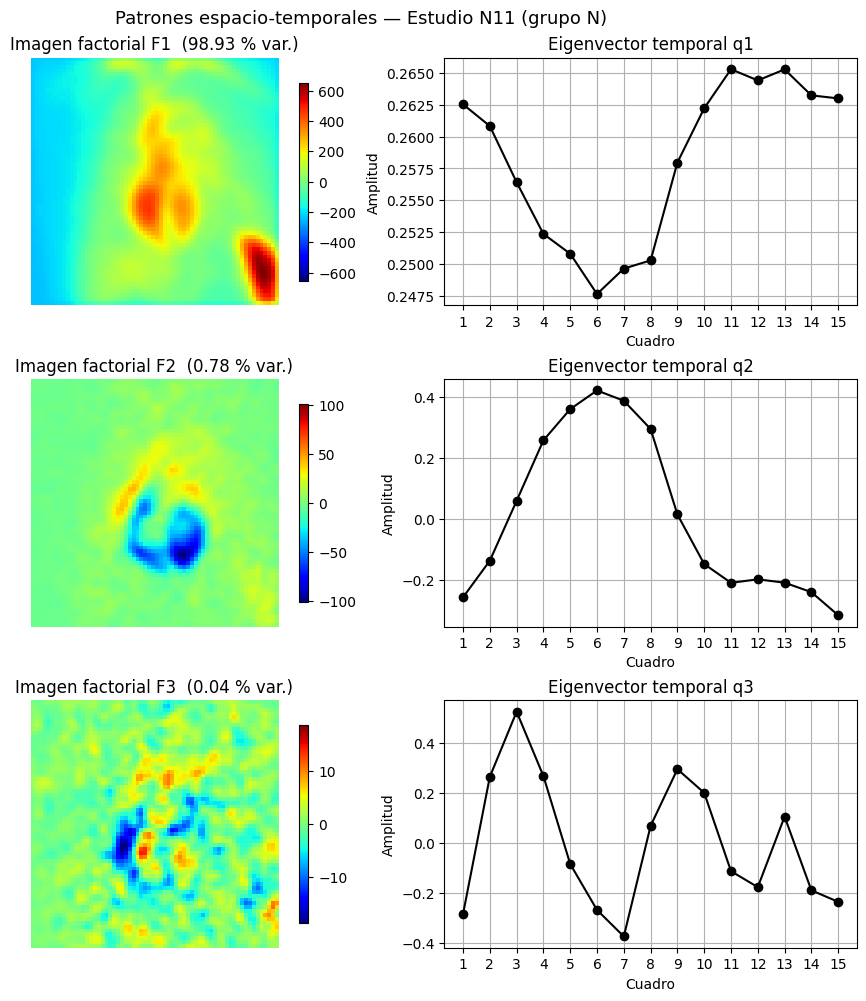

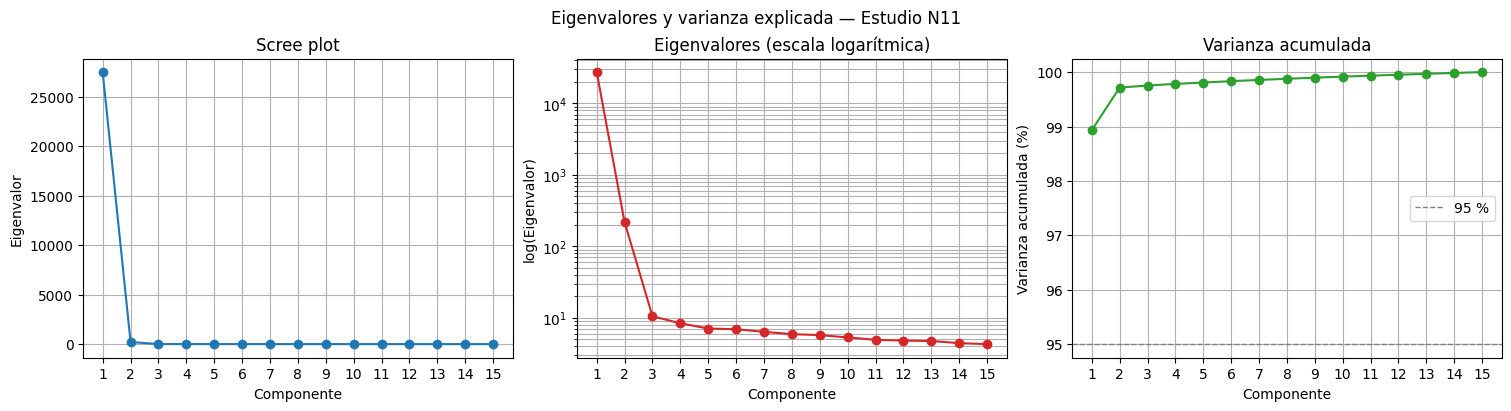

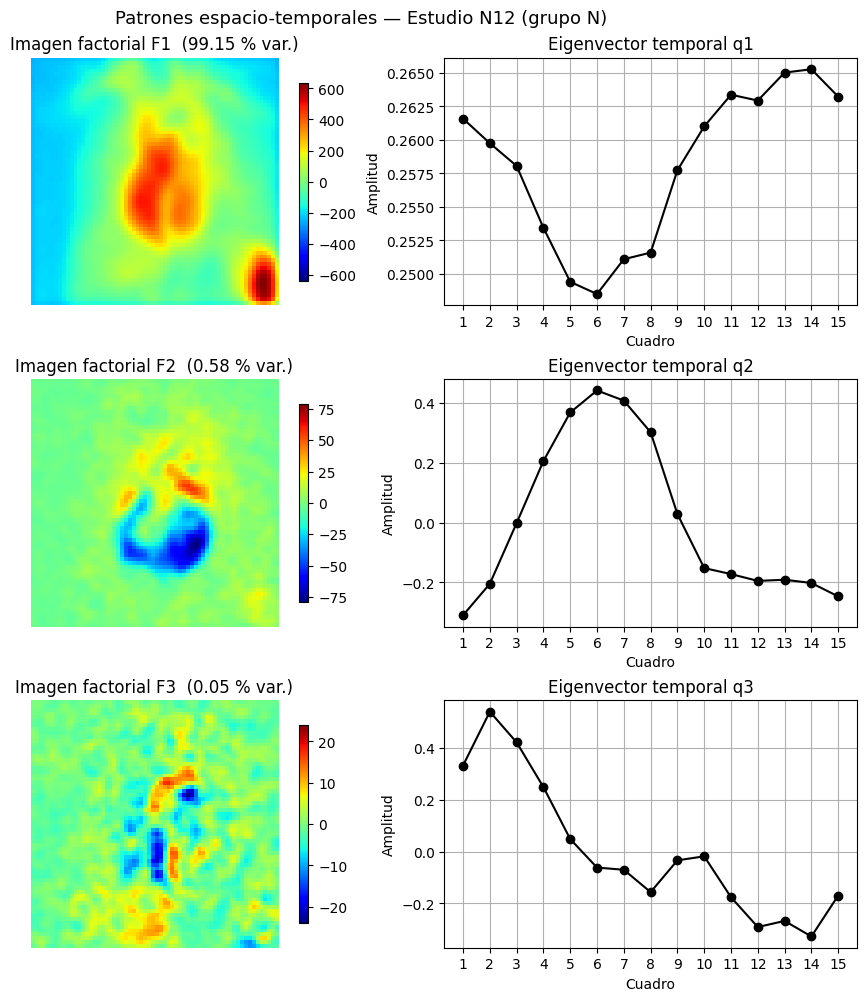

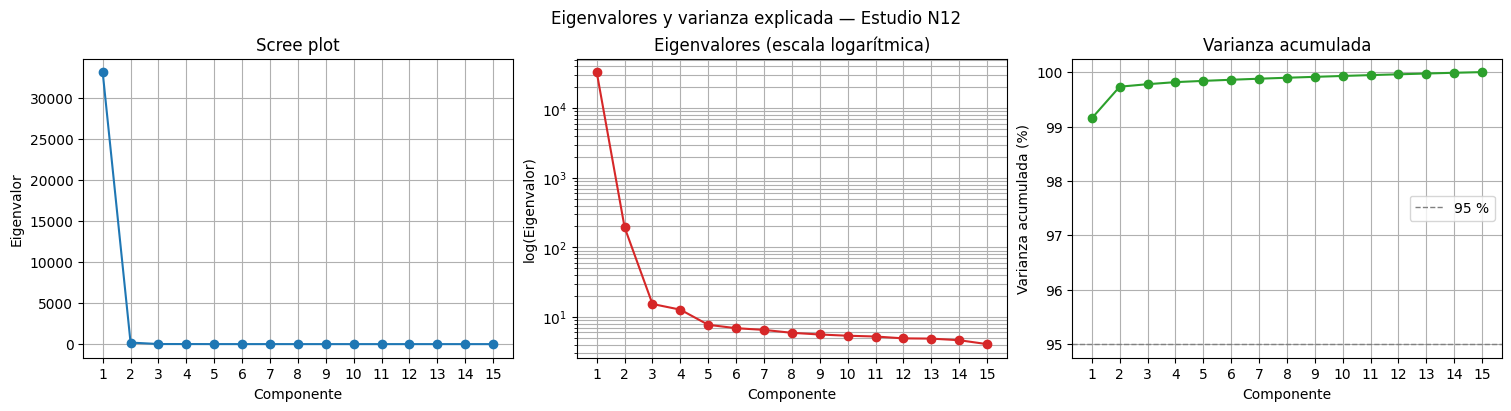

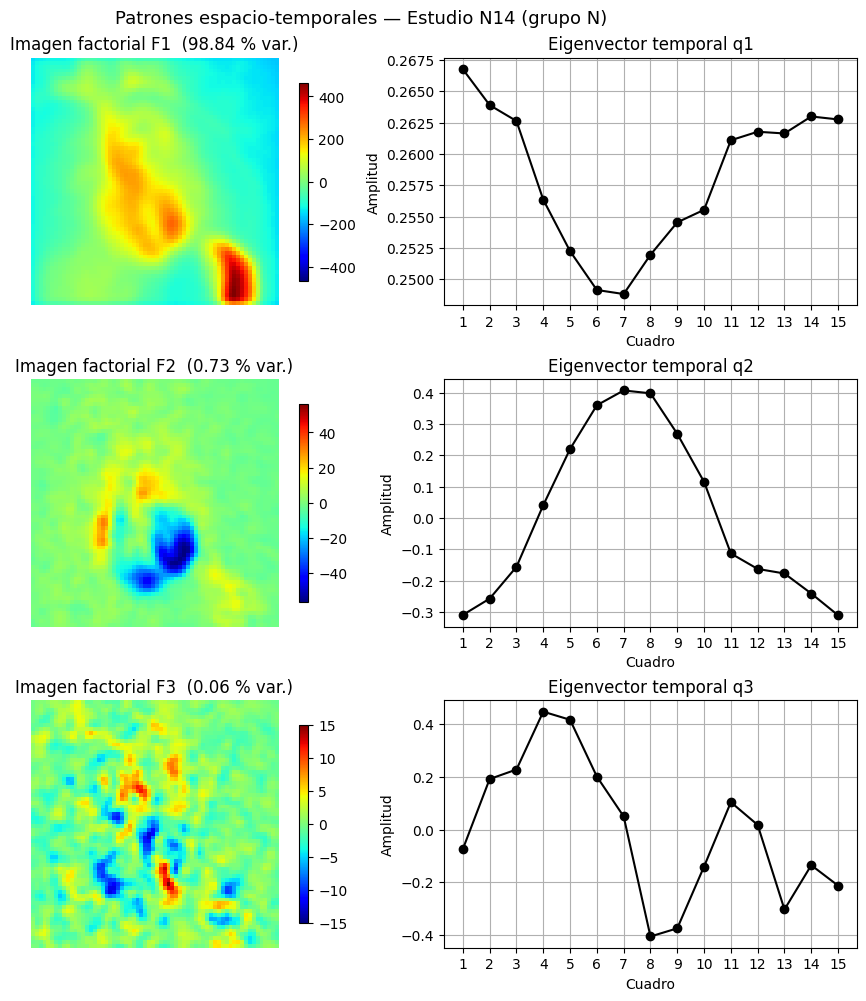

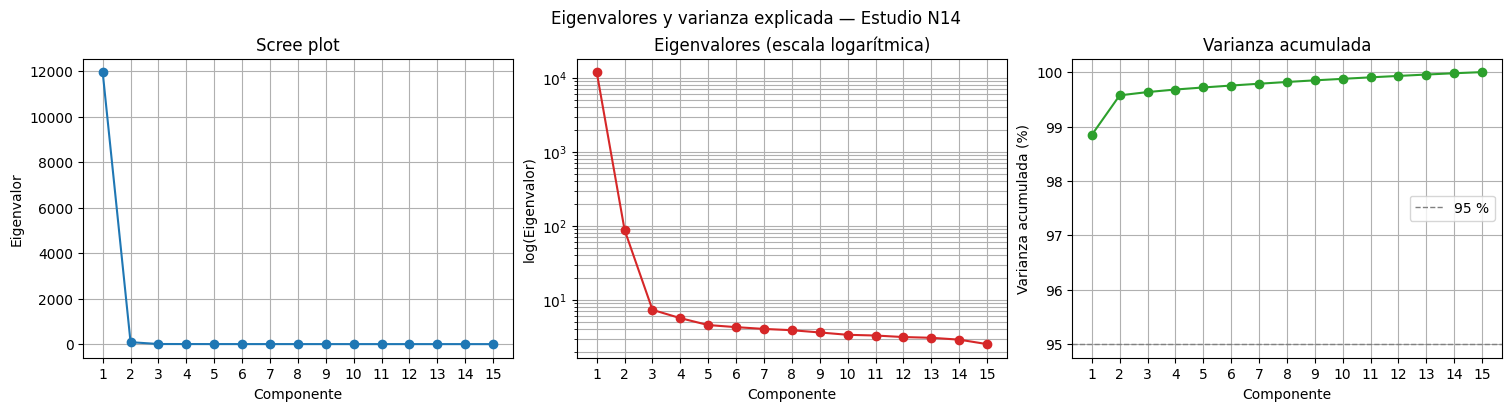

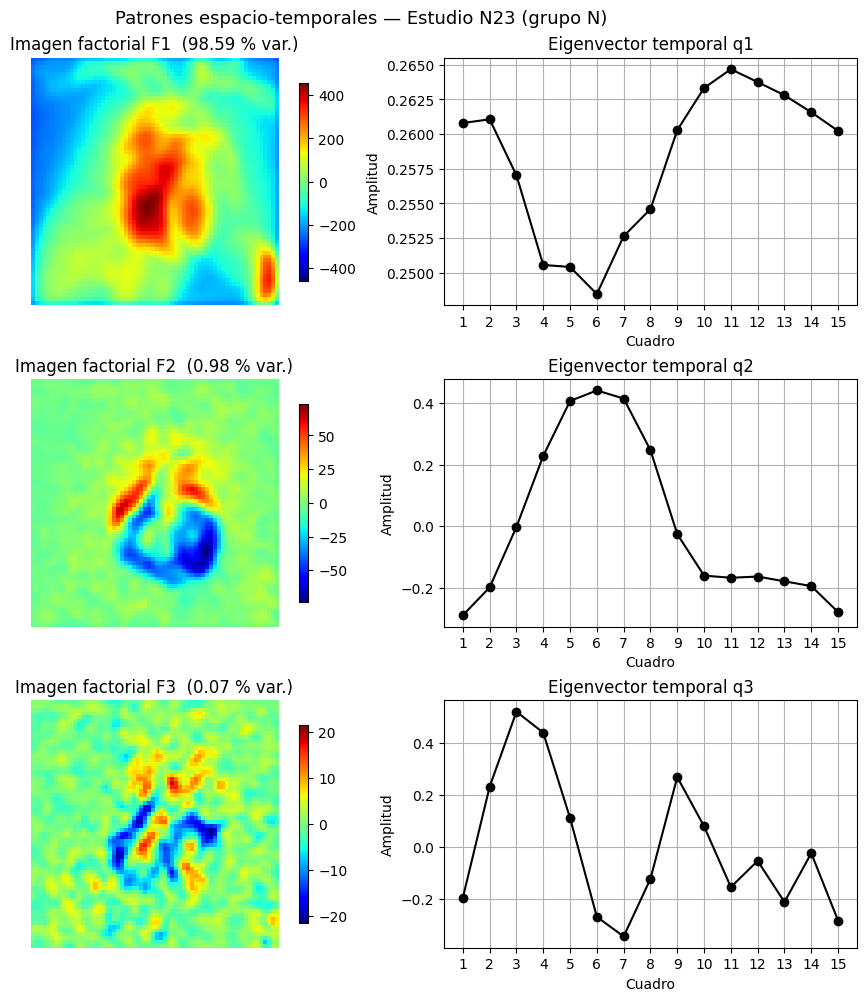

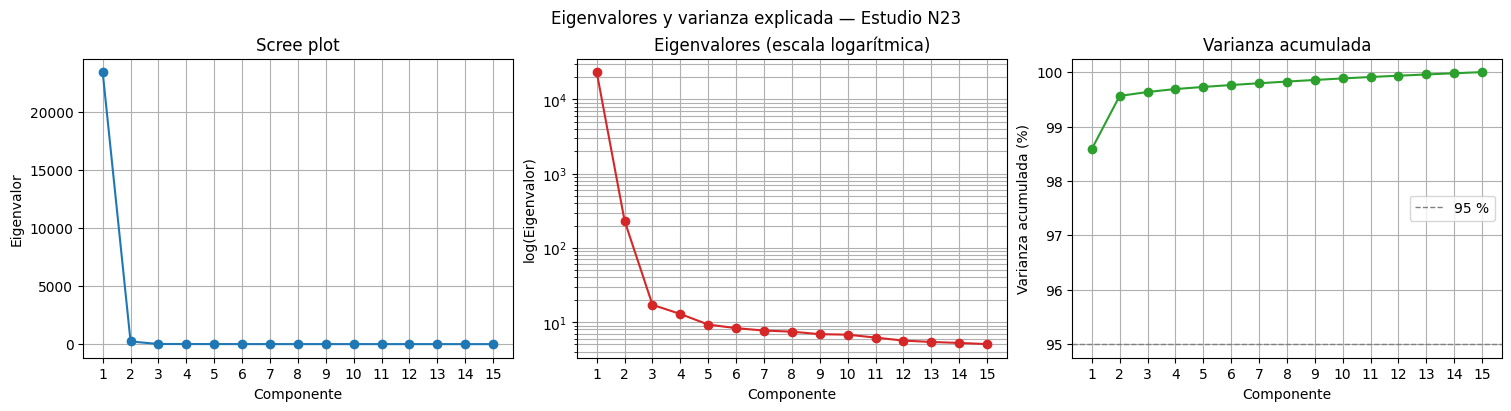

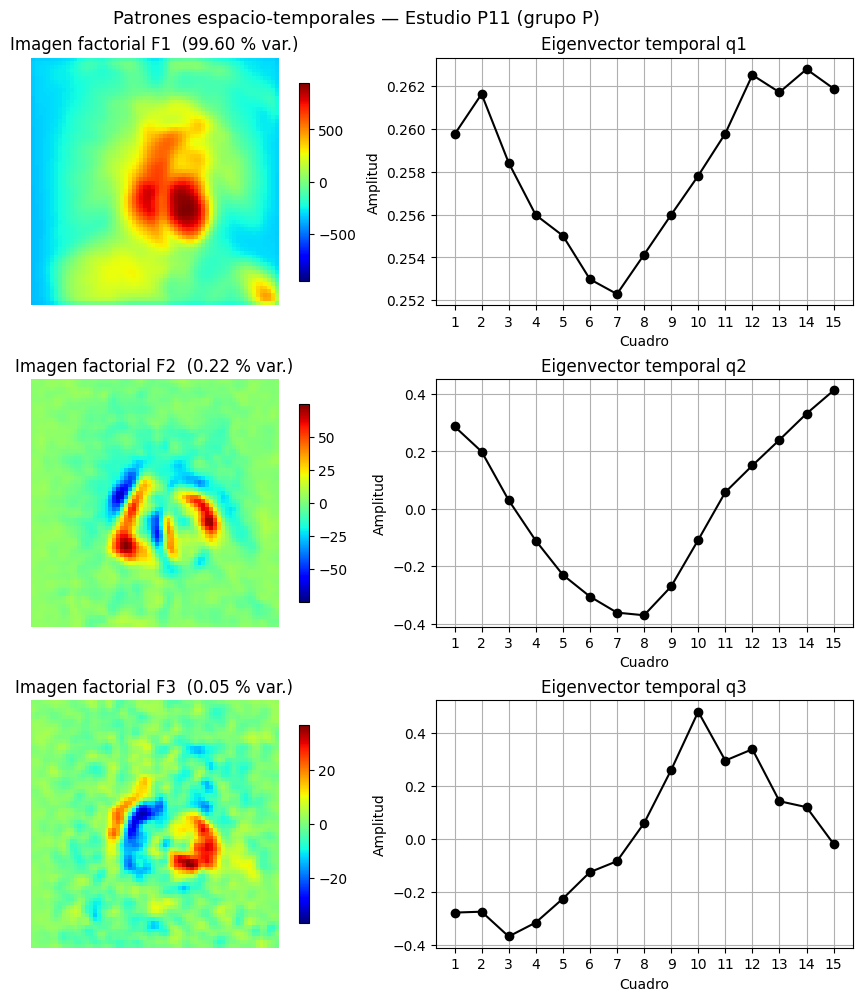

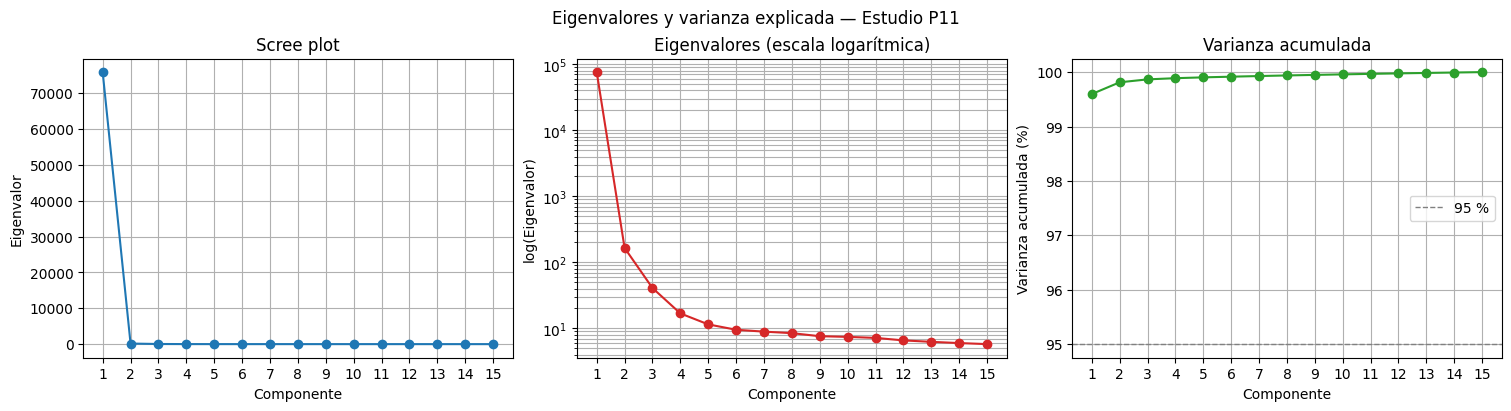

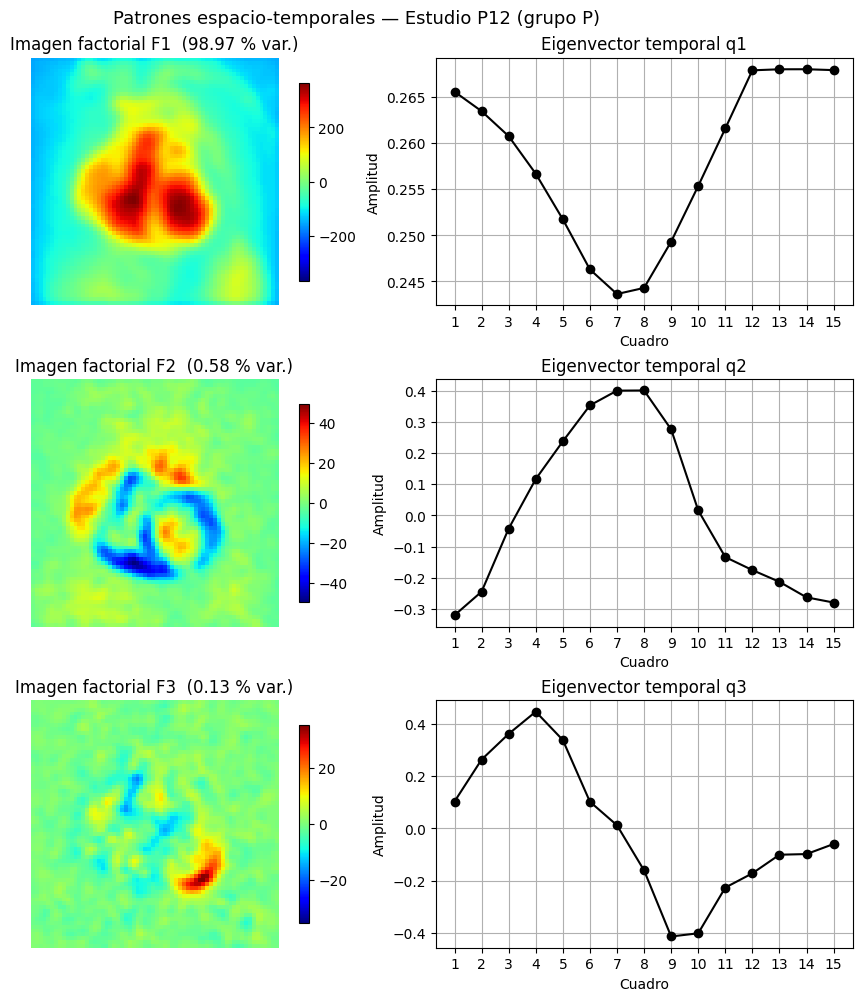

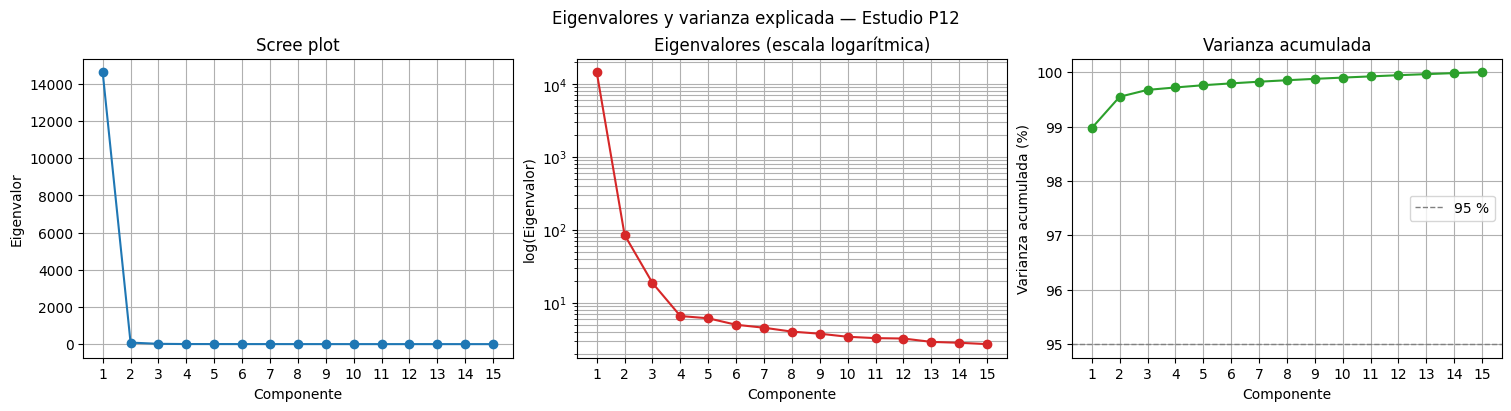

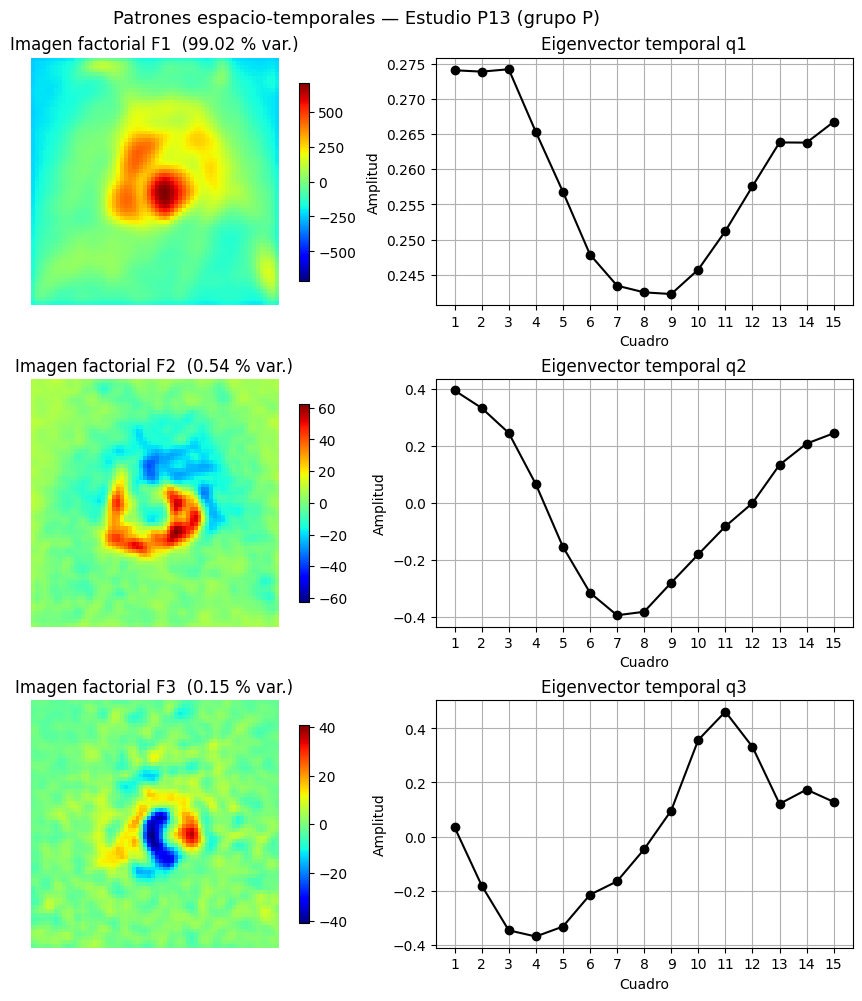

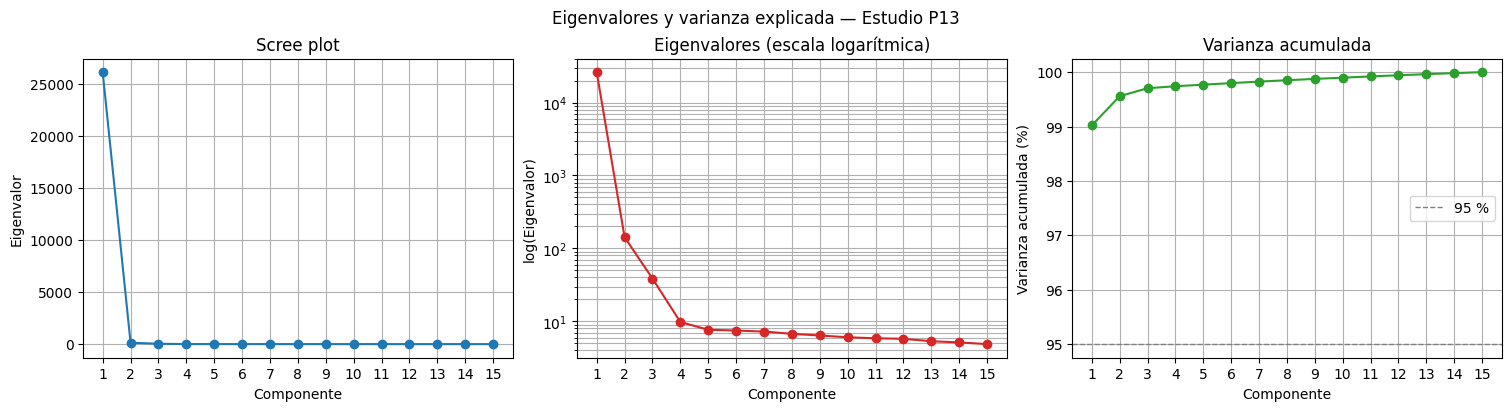

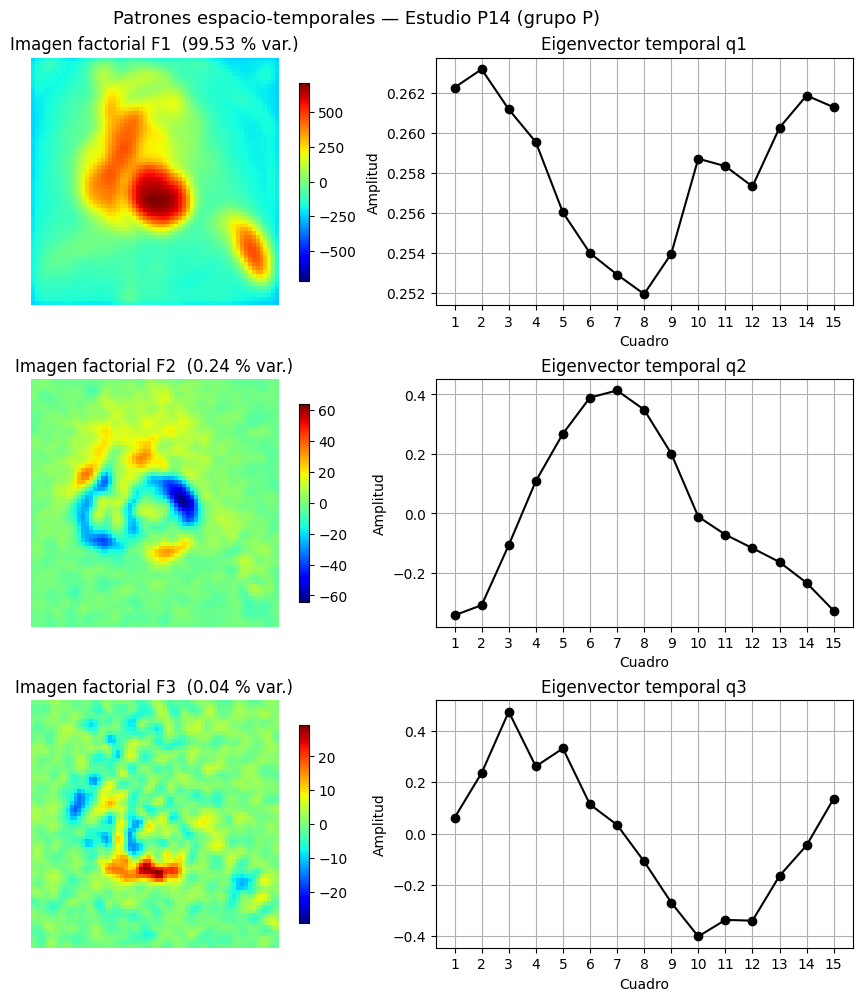

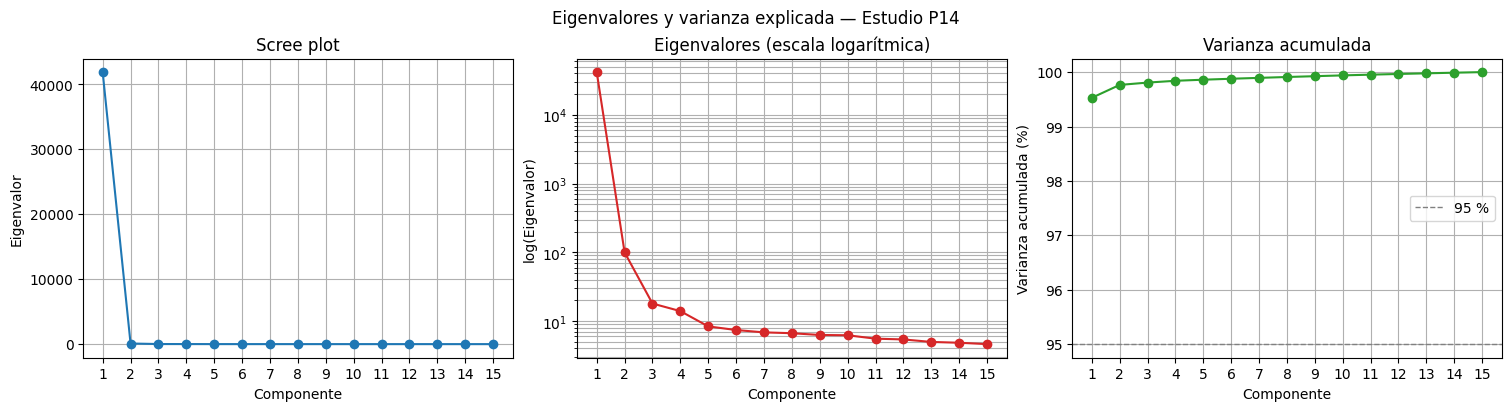

In [8]:
def graficar_factores_temporales(resultado, n_componentes=3):
    """Grafica las imágenes factoriales F_i junto a sus eigenvectores q_i."""
    F = resultado["factores"]
    Q = resultado["eigenvectores"]
    ve = resultado["varianza_explicada"]
    nombre = resultado["nombre"]

    fig, axs = plt.subplots(n_componentes, 2, figsize=(10, 3.3 * n_componentes),
                             constrained_layout=True)
    cuadros = np.arange(1, Q.shape[0] + 1)

    for i in range(n_componentes):
        imagen = F[:, i].reshape(64, 64)
        limite = np.max(np.abs(imagen))
        vmin, vmax = -limite, limite

        ax_img = axs[i, 0]
        im = ax_img.imshow(imagen, cmap="jet", vmin=vmin, vmax=vmax)
        ax_img.set_title(f"Imagen factorial F{i + 1}  ({ve[i] * 100:.2f} % var.)")
        ax_img.axis("off")
        fig.colorbar(im, ax=ax_img, shrink=0.8)

        ax_q = axs[i, 1]
        ax_q.plot(cuadros, Q[:, i], marker="o", color="black")
        ax_q.set_title(f"Eigenvector temporal q{i + 1}")
        ax_q.set_xlabel("Cuadro")
        ax_q.set_ylabel("Amplitud")
        ax_q.set_xticks(cuadros)
        ax_q.grid(True)

    fig.suptitle(f"Patrones espacio-temporales — Estudio {nombre} (grupo {resultado['grupo']})",
                 fontsize=13)
    plt.show()
    plt.close(fig)


def graficar_eigenvalores(resultado):
    """Muestra el scree plot, su versión logarítmica y la varianza acumulada."""
    vals = resultado["eigenvalores"]
    va = resultado["varianza_acumulada"]
    idx = np.arange(1, len(vals) + 1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    axs[0].plot(idx, vals, marker="o", color="tab:blue")
    axs[0].set_title("Scree plot")
    axs[0].set_xlabel("Componente")
    axs[0].set_ylabel("Eigenvalor")
    axs[0].set_xticks(idx)
    axs[0].grid(True)

    vals_seguros = np.where(vals > 0, vals, np.nan)  # evita log(0) / log(negativo)
    axs[1].semilogy(idx, vals_seguros, marker="o", color="tab:red")
    axs[1].set_title("Eigenvalores (escala logarítmica)")
    axs[1].set_xlabel("Componente")
    axs[1].set_ylabel("log(Eigenvalor)")
    axs[1].set_xticks(idx)
    axs[1].grid(True, which="both")

    axs[2].plot(idx, va * 100, marker="o", color="tab:green")
    axs[2].axhline(95, color="gray", linestyle="--", linewidth=1, label="95 %")
    axs[2].set_title("Varianza acumulada")
    axs[2].set_xlabel("Componente")
    axs[2].set_ylabel("Varianza acumulada (%)")
    axs[2].set_xticks(idx)
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(f"Eigenvalores y varianza explicada — Estudio {resultado['nombre']}")
    plt.show()
    plt.close(fig)


for ident, resultado in resultados.items():
    graficar_factores_temporales(resultado, n_componentes=3)
    graficar_eigenvalores(resultado)

## 13. Reconstrucción con componentes principales

`reconstruir_estudio` reconstruye el estudio utilizando únicamente las
primeras $k$ componentes ($\hat{X}_k = F_k Q_k^T + \bar{X}$) y calcula el
RMSE respecto a los datos originales. Esto es una **demostración de
reducción dimensional**, no un procedimiento de filtrado clínico: un RMSE
menor solamente indica una aproximación numérica más cercana a los datos
originales, no una mejora en la calidad diagnóstica del estudio.

Se muestra la comparación visual para dos estudios representativos (uno de
cada grupo, `N11` y `P11`); el RMSE con $k=1,2,3$ para los ocho estudios se
calcula a continuación y se incorpora más adelante a la tabla resumen.

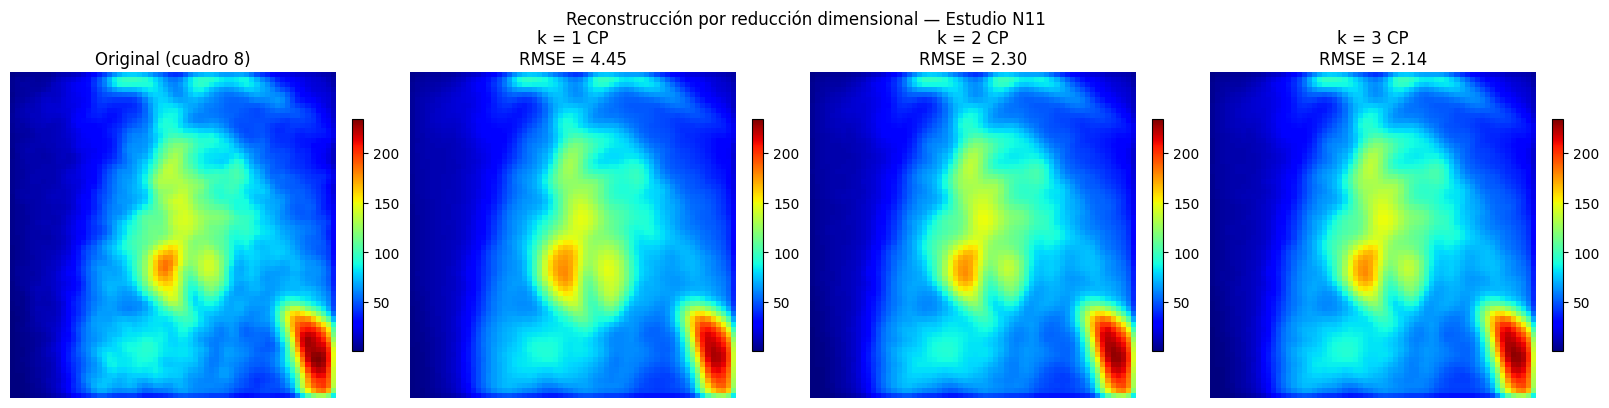

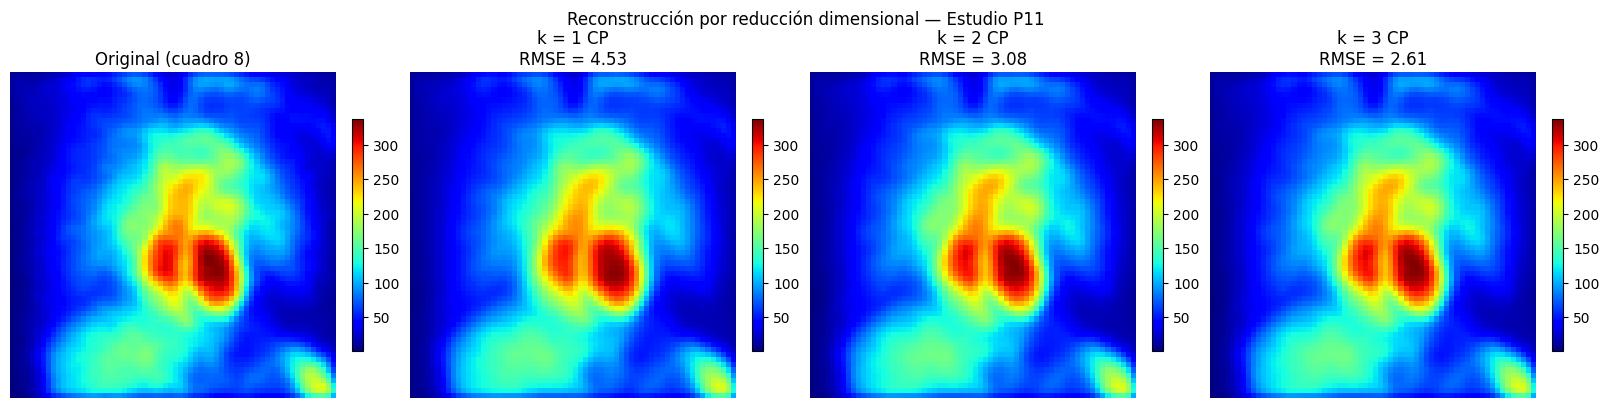

,RMSE_k=1,RMSE_k=2,RMSE_k=3
N11,4.4464,2.2960,2.1387
N12,4.3502,2.4449,2.2261
N14,3.0515,1.8568,1.7202
N23,4.7290,2.6317,2.4052
P11,4.5289,3.0849,2.6072
P12,3.1845,2.1128,1.7945
P13,4.1546,2.7914,2.2848
P14,3.6418,2.5706,2.3256


In [9]:
def reconstruir_estudio(resultado, k):
    """Reconstruye un estudio usando las primeras k componentes principales."""
    F = resultado["factores"]
    Q = resultado["eigenvectores"]
    media = resultado["media"]
    X = resultado["X"]

    X_rec = F[:, :k] @ Q[:, :k].T + media
    assert X_rec.shape == (4096, 15)

    volumen_rec = X_rec.reshape(64, 64, 15)
    rmse = float(np.sqrt(np.mean((X_rec - X) ** 2)))

    return {"k": k, "X_reconstruida": X_rec, "volumen": volumen_rec, "rmse": rmse}


def graficar_reconstrucciones(resultado, ks=(1, 2, 3), cuadro=7):
    """Compara un cuadro original con sus reconstrucciones para varios k."""
    volumen_original = resultado["X"].reshape(64, 64, 15)
    original = volumen_original[:, :, cuadro]

    fig, axs = plt.subplots(1, len(ks) + 1, figsize=(4 * (len(ks) + 1), 4),
                             constrained_layout=True)
    im0 = axs[0].imshow(original, cmap="jet")
    axs[0].set_title(f"Original (cuadro {cuadro + 1})")
    axs[0].axis("off")
    fig.colorbar(im0, ax=axs[0], shrink=0.7)

    for j, k in enumerate(ks, start=1):
        rec = reconstruir_estudio(resultado, k)
        imagen_rec = rec["volumen"][:, :, cuadro]
        im = axs[j].imshow(imagen_rec, cmap="jet", vmin=original.min(), vmax=original.max())
        axs[j].set_title(f"k = {k} CP\nRMSE = {rec['rmse']:.2f}")
        axs[j].axis("off")
        fig.colorbar(im, ax=axs[j], shrink=0.7)

    fig.suptitle(f"Reconstrucción por reducción dimensional — Estudio {resultado['nombre']}")
    plt.show()
    plt.close(fig)


for ident in ["N11", "P11"]:
    graficar_reconstrucciones(resultados[ident], ks=(1, 2, 3), cuadro=7)

rmse_por_estudio = {
    ident: {k: reconstruir_estudio(r, k)["rmse"] for k in (1, 2, 3)}
    for ident, r in resultados.items()
}
pd.DataFrame(rmse_por_estudio).T.rename(columns=lambda k: f"RMSE_k={k}")

## 14. Validación con scikit-learn

El cálculo manual es el procedimiento principal de esta práctica, con fines
educativos. A continuación se valida, únicamente para el estudio `N11`,
que los resultados coinciden con los de `sklearn.decomposition.PCA`:

- Se comparan los eigenvalores (`explained_variance_`).
- Se compara la varianza explicada (`explained_variance_ratio_`).
- Como el signo de los componentes es arbitrario, la equivalencia de
  subespacios se verifica con el valor absoluto del producto interno entre
  cada eigenvector manual y su componente de sklearn (debe ser ≈ 1), en
  lugar de exigir igualdad directa de signos.

In [10]:
resultado_val = resultados["N11"]

pca_sklearn = PCA(n_components=15)
pca_sklearn.fit(resultado_val["X"])

eigenvalores_sklearn = pca_sklearn.explained_variance_
ve_sklearn = pca_sklearn.explained_variance_ratio_

comparacion_sklearn = pd.DataFrame({
    "Componente": np.arange(1, 16),
    "Eigenvalor_manual": resultado_val["eigenvalores"],
    "Eigenvalor_sklearn": eigenvalores_sklearn,
    "VarExplicada_manual_%": resultado_val["varianza_explicada"] * 100,
    "VarExplicada_sklearn_%": ve_sklearn * 100,
})

assert np.allclose(resultado_val["eigenvalores"], eigenvalores_sklearn, rtol=1e-4, atol=1e-6), \
    "Los eigenvalores manuales y de sklearn no coinciden"
assert np.allclose(resultado_val["varianza_explicada"], ve_sklearn, rtol=1e-4, atol=1e-6), \
    "La varianza explicada manual y de sklearn no coincide"

# Equivalencia de subespacios (independiente del signo)
producto_interno = np.abs(np.diag(pca_sklearn.components_ @ resultado_val["eigenvectores"]))
assert np.allclose(producto_interno, 1.0, atol=1e-4), \
    "Los eigenvectores manuales y de sklearn no generan el mismo subespacio"

print("Validación contra sklearn (estudio N11): OK")
print(f"  |producto interno| por componente (debe ser ~1): {producto_interno}")
comparacion_sklearn

Validación contra sklearn (estudio N11): OK
  |producto interno| por componente (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Componente,Eigenvalor_manual,Eigenvalor_sklearn,VarExplicada_manual_%,VarExplicada_sklearn_%
0,1,27489.5660,27489.5660,98.9324,98.9324
1,2,217.5366,217.5366,0.7829,0.7829
2,3,10.4680,10.4680,0.0377,0.0377
3,4,8.3574,8.3574,0.0301,0.0301
4,5,7.0543,7.0543,0.0254,0.0254
5,6,6.8983,6.8983,0.0248,0.0248
6,7,6.3400,6.3400,0.0228,0.0228
7,8,5.8889,5.8889,0.0212,0.0212
8,9,5.7115,5.7115,0.0206,0.0206
9,10,5.2931,5.2931,0.0190,0.0190


## 15. Tabla resumen

Se construye una tabla con una fila por estudio, calculada íntegramente a
partir de los resultados del ACP (ningún valor se escribe manualmente). El
número de componentes necesario para alcanzar 95 % y 99 % de varianza
acumulada se obtiene con `np.searchsorted` sobre la varianza acumulada.

In [11]:
filas_resumen = []
for ident, r in resultados.items():
    ve = r["varianza_explicada"]
    va = r["varianza_acumulada"]
    vals = r["eigenvalores"]

    comp_95 = int(np.searchsorted(va, 0.95) + 1)
    comp_99 = int(np.searchsorted(va, 0.99) + 1)
    rmse_k = {k: reconstruir_estudio(r, k)["rmse"] for k in (1, 2, 3)}

    filas_resumen.append({
        "Estudio": ident,
        "Grupo": r["grupo"],
        "Eigenvalor_1": vals[0],
        "Eigenvalor_2": vals[1],
        "Eigenvalor_3": vals[2],
        "Varianza_CP1_%": ve[0] * 100,
        "Varianza_CP2_%": ve[1] * 100,
        "Varianza_CP3_%": ve[2] * 100,
        "Varianza_acumulada_3_%": va[2] * 100,
        "Lambda2_sobre_Lambda1": vals[1] / vals[0],
        "Lambda3_sobre_Lambda1": vals[2] / vals[0],
        "Componentes_para_95_%": comp_95,
        "Componentes_para_99_%": comp_99,
        "RMSE_reconstruccion_1_CP": rmse_k[1],
        "RMSE_reconstruccion_2_CP": rmse_k[2],
        "RMSE_reconstruccion_3_CP": rmse_k[3],
    })

tabla_resumen = (
    pd.DataFrame(filas_resumen)
    .sort_values(["Grupo", "Estudio"])
    .reset_index(drop=True)
)

assert len(tabla_resumen) == 8
assert not tabla_resumen.isna().to_numpy().any(), "La tabla resumen contiene NaN"
assert np.isfinite(tabla_resumen.select_dtypes(include=[float, int]).to_numpy()).all(), \
    "La tabla resumen contiene valores infinitos"

ruta_csv = DIR_BASE / "resultados_pca_vrie.csv"
tabla_resumen.to_csv(ruta_csv, index=False)
print(f"Tabla guardada en: {ruta_csv}")

tabla_resumen

Tabla guardada en: c:\Users\PC\Downloads\resultados_pca_vrie.csv


,Estudio,Grupo,Eigenvalor_1,Eigenvalor_2,Eigenvalor_3,Varianza_CP1_%,Varianza_CP2_%,Varianza_CP3_%,Varianza_acumulada_3_%,Lambda2_sobre_Lambda1,Lambda3_sobre_Lambda1,Componentes_para_95_%,Componentes_para_99_%,RMSE_reconstruccion_1_CP,RMSE_reconstruccion_2_CP,RMSE_reconstruccion_3_CP
0,N11,N,27489.5660,217.5366,10.4680,98.9324,0.7829,0.0377,99.7530,0.0079,0.0004,1,2,4.4464,2.2960,2.1387
1,N12,N,33143.7671,194.2430,15.3345,99.1506,0.5811,0.0459,99.7776,0.0059,0.0005,1,1,4.3502,2.4449,2.2261
2,N14,N,11956.5196,87.9851,7.3284,98.8450,0.7274,0.0606,99.6330,0.0074,0.0006,1,2,3.0515,1.8568,1.7202
3,N23,N,23389.7788,231.6288,17.1118,98.5857,0.9763,0.0721,99.6341,0.0099,0.0007,1,2,4.7290,2.6317,2.4052
4,P11,P,75899.4449,164.9486,40.7955,99.5962,0.2164,0.0535,99.8662,0.0022,0.0005,1,1,4.5289,3.0849,2.6072
5,P12,P,14634.2528,85.1764,18.6601,98.9710,0.5760,0.1262,99.6732,0.0058,0.0013,1,2,3.1845,2.1128,1.7945
6,P13,P,26140.4362,142.0692,38.5827,99.0190,0.5382,0.1461,99.7033,0.0054,0.0015,1,1,4.1546,2.7914,2.2848
7,P14,P,41892.5349,99.8415,17.9955,99.5273,0.2372,0.0428,99.8072,0.0024,0.0004,1,1,3.6418,2.5706,2.3256


## 16. Comparación descriptiva entre los grupos N y P

Esta sección es **exploratoria y descriptiva**: solamente se cuenta con
cuatro estudios por grupo y no se dispone de metadatos clínicos completos,
por lo que no se realizan pruebas de significancia estadística (t de
Student, ANOVA) ni se extraen conclusiones poblacionales.

### 16.1 Montaje de imágenes factoriales

Se comparan $F_1$, $F_2$ y $F_3$ de los ocho estudios en una sola figura
(una fila por estudio, agrupados N arriba y P abajo). **Únicamente para
fines de visualización**, cada imagen se normaliza dividiendo entre su
propio máximo valor absoluto (no se modifican los datos usados en los
cálculos).

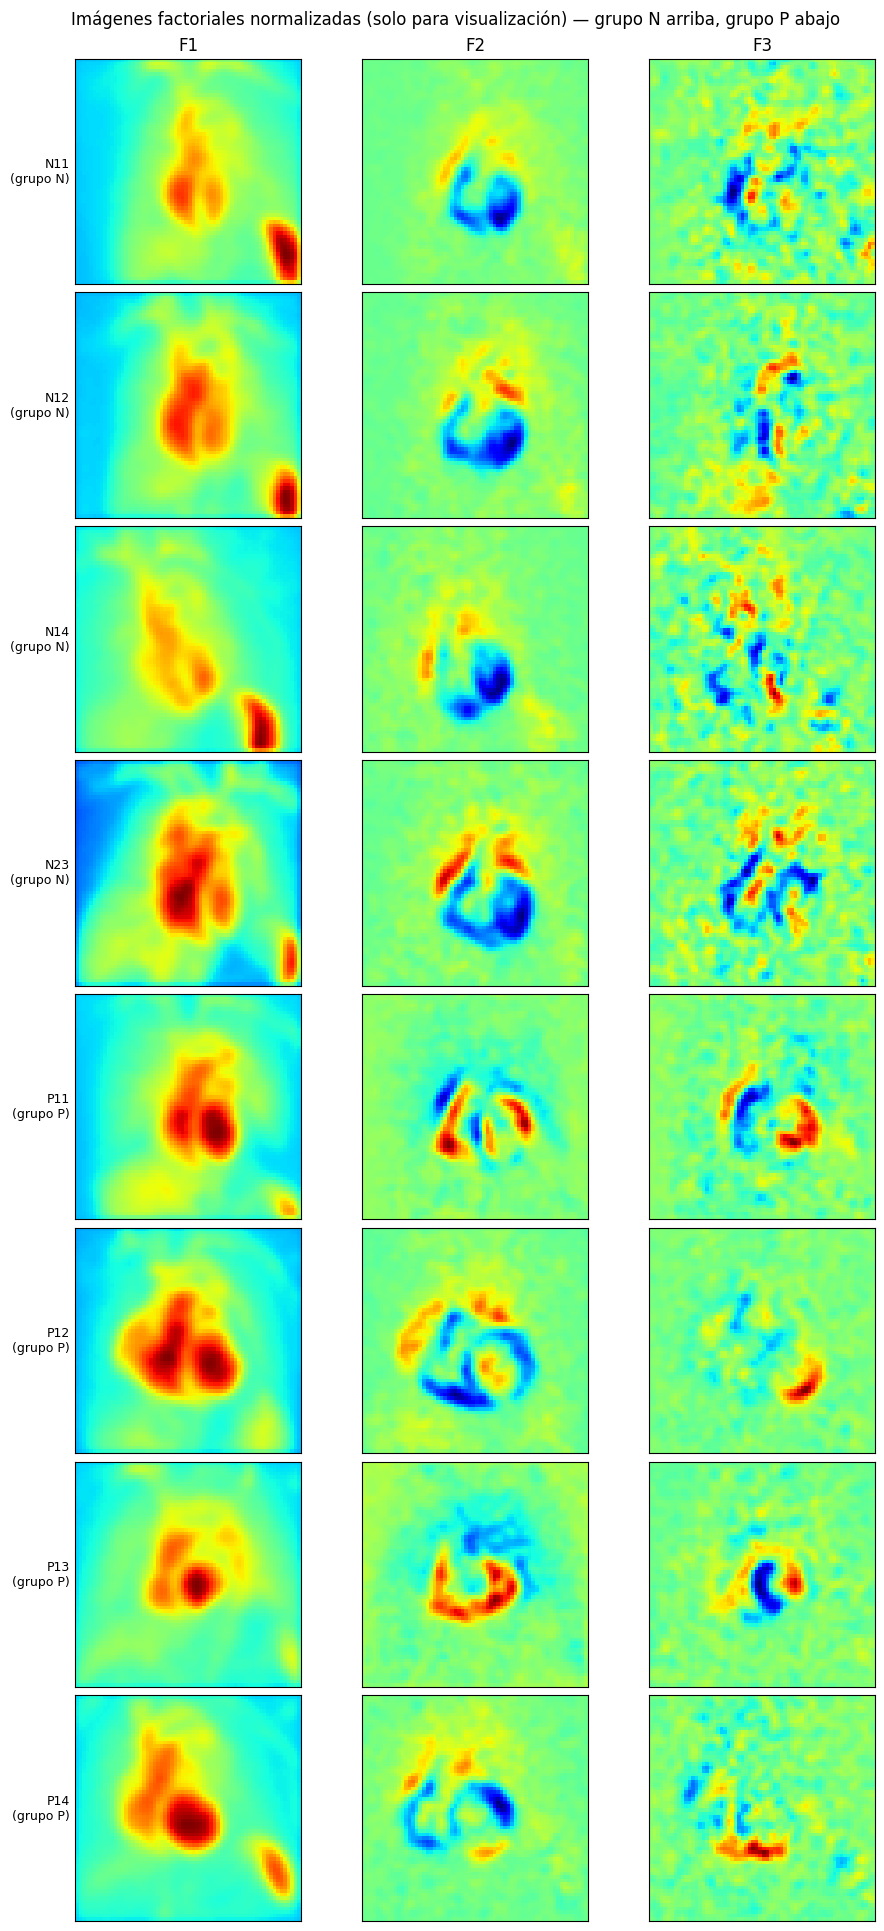

In [12]:
def graficar_montaje_factores(resultados_dict, n_componentes=3):
    """Monta F1..Fn de todos los estudios, normalizados solo para visualizar."""
    nombres = list(resultados_dict.keys())
    fig, axs = plt.subplots(len(nombres), n_componentes,
                             figsize=(3 * n_componentes, 2.4 * len(nombres)),
                             constrained_layout=True)

    for fila, nombre in enumerate(nombres):
        r = resultados_dict[nombre]
        F = r["factores"]
        for col in range(n_componentes):
            imagen = F[:, col].reshape(64, 64)
            limite = np.max(np.abs(imagen))
            imagen_norm = imagen / limite if limite > 0 else imagen

            ax = axs[fila, col]
            ax.imshow(imagen_norm, cmap="jet", vmin=-1, vmax=1)
            ax.set_xticks([])
            ax.set_yticks([])
            if fila == 0:
                ax.set_title(f"F{col + 1}")
            if col == 0:
                ax.set_ylabel(f"{nombre}\n(grupo {r['grupo']})", fontsize=9, rotation=0,
                               ha="right", va="center")

    fig.suptitle("Imágenes factoriales normalizadas (solo para visualización) — "
                  "grupo N arriba, grupo P abajo", fontsize=12)
    plt.show()
    plt.close(fig)


graficar_montaje_factores(resultados, n_componentes=3)

### 16.2 Comparación de eigenvalores entre estudios y grupos

Se grafican los eigenvalores de los ocho estudios en escala logarítmica,
diferenciando grupo N (línea continua) de grupo P (línea discontinua), y se
muestra la varianza explicada promedio ± desviación estándar por grupo.
Como los eigenvalores absolutos dependen de la intensidad total de cada
estudio (cuentas totales detectadas), también se comparan los cocientes
$\lambda_2/\lambda_1$ y $\lambda_3/\lambda_1$, que son adimensionales y
menos sensibles a la intensidad global.

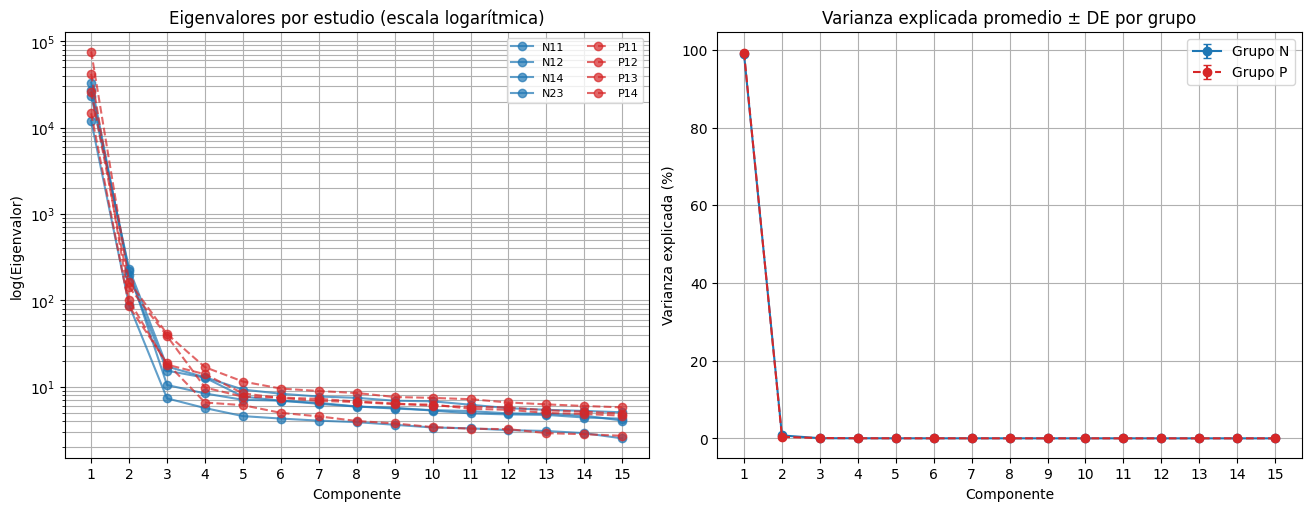

In [13]:
def graficar_comparacion_eigenvalores(resultados_dict):
    """Compara eigenvalores y varianza explicada por grupo (N vs. P)."""
    colores = {"N": "tab:blue", "P": "tab:red"}
    estilos = {"N": "-", "P": "--"}
    n_componentes = len(next(iter(resultados_dict.values()))["eigenvalores"])
    idx = np.arange(1, n_componentes + 1)

    fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    for nombre, r in resultados_dict.items():
        grupo = r["grupo"]
        vals_seguros = np.where(r["eigenvalores"] > 0, r["eigenvalores"], np.nan)
        axs[0].semilogy(idx, vals_seguros, estilos[grupo], marker="o",
                         color=colores[grupo], alpha=0.7, label=nombre)

    axs[0].set_title("Eigenvalores por estudio (escala logarítmica)")
    axs[0].set_xlabel("Componente")
    axs[0].set_ylabel("log(Eigenvalor)")
    axs[0].set_xticks(idx)
    axs[0].legend(fontsize=8, ncol=2)
    axs[0].grid(True, which="both")

    for grupo in ["N", "P"]:
        matriz_ve = np.array([
            r["varianza_explicada"] for r in resultados_dict.values() if r["grupo"] == grupo
        ]) * 100
        media_ve = matriz_ve.mean(axis=0)
        std_ve = matriz_ve.std(axis=0)
        axs[1].errorbar(idx, media_ve, yerr=std_ve, marker="o", capsize=3,
                         color=colores[grupo], linestyle=estilos[grupo],
                         label=f"Grupo {grupo}")

    axs[1].set_title("Varianza explicada promedio ± DE por grupo")
    axs[1].set_xlabel("Componente")
    axs[1].set_ylabel("Varianza explicada (%)")
    axs[1].set_xticks(idx)
    axs[1].legend()
    axs[1].grid(True)

    plt.show()
    plt.close(fig)


graficar_comparacion_eigenvalores(resultados)

### 16.3 Resumen descriptivo por grupo

Media y desviación estándar, por grupo, de la varianza de CP1–CP3, la
varianza acumulada de las primeras tres componentes, los cocientes
$\lambda_2/\lambda_1$, $\lambda_3/\lambda_1$ y el RMSE de las
reconstrucciones con 1, 2 y 3 componentes.

In [14]:
resumen_grupo = tabla_resumen.groupby("Grupo").agg(
    Varianza_CP1_media=("Varianza_CP1_%", "mean"),
    Varianza_CP1_DE=("Varianza_CP1_%", "std"),
    Varianza_CP2_media=("Varianza_CP2_%", "mean"),
    Varianza_CP2_DE=("Varianza_CP2_%", "std"),
    Varianza_CP3_media=("Varianza_CP3_%", "mean"),
    Varianza_CP3_DE=("Varianza_CP3_%", "std"),
    Var_acumulada_3_media=("Varianza_acumulada_3_%", "mean"),
    Var_acumulada_3_DE=("Varianza_acumulada_3_%", "std"),
    Lambda2_sobre_1_media=("Lambda2_sobre_Lambda1", "mean"),
    Lambda2_sobre_1_DE=("Lambda2_sobre_Lambda1", "std"),
    Lambda3_sobre_1_media=("Lambda3_sobre_Lambda1", "mean"),
    Lambda3_sobre_1_DE=("Lambda3_sobre_Lambda1", "std"),
    RMSE_1CP_media=("RMSE_reconstruccion_1_CP", "mean"),
    RMSE_1CP_DE=("RMSE_reconstruccion_1_CP", "std"),
    RMSE_2CP_media=("RMSE_reconstruccion_2_CP", "mean"),
    RMSE_2CP_DE=("RMSE_reconstruccion_2_CP", "std"),
    RMSE_3CP_media=("RMSE_reconstruccion_3_CP", "mean"),
    RMSE_3CP_DE=("RMSE_reconstruccion_3_CP", "std"),
)
resumen_grupo

,Varianza_CP1_media,Varianza_CP1_DE,Varianza_CP2_media,Varianza_CP2_DE,Varianza_CP3_media,Varianza_CP3_DE,Var_acumulada_3_media,Var_acumulada_3_DE,Lambda2_sobre_1_media,Lambda2_sobre_1_DE,Lambda3_sobre_1_media,Lambda3_sobre_1_DE,RMSE_1CP_media,RMSE_1CP_DE,RMSE_2CP_media,RMSE_2CP_DE,RMSE_3CP_media,RMSE_3CP_DE
Grupo,,,,,,,,,,,,,,,,,,
N,98.8784,0.2337,0.7669,0.1635,0.0541,0.0153,99.6994,0.0767,0.0078,0.0017,0.0005,0.0002,4.1443,0.7460,2.3074,0.3303,2.1226,0.2903
P,99.2784,0.3290,0.3920,0.1915,0.0922,0.0517,99.7625,0.0898,0.0040,0.0019,0.0009,0.0005,3.8774,0.5879,2.6399,0.4097,2.2530,0.3376


## 17. Interpretación de los componentes

- $F_1$ y $q_1$ suelen representar el **patrón espacio-temporal dominante**:
  la estructura compartida por la mayoría de los píxeles cardíacos y su
  evolución global durante los 15 cuadros (típicamente asociada al llenado
  y vaciado global de las cavidades).
- $F_2$ y $q_2$ representan la **siguiente fuente de variabilidad**, que
  puede relacionarse con diferencias entre fases de contracción y
  relajación, pero esta interpretación debe apoyarse siempre en la forma de
  la imagen y de la curva temporal correspondientes, no darse por sentada.
- $F_3$ y $q_3$ representan una **fuente adicional de variabilidad**, que
  puede reflejar dinámica regional, pequeñas diferencias espaciales o
  ruido de adquisición.
- Una componente **no equivale automáticamente** a una estructura anatómica
  ni a una condición clínica. El ACP maximiza varianza matemática, no
  relevancia fisiológica o diagnóstica.
- El **signo** de $F_i$ y $q_i$ es arbitrario (se fijó únicamente por
  reproducibilidad visual, sección 9).
- Una **varianza explicada pequeña no implica falta de interés
  fisiológico**: $F_3$, por ejemplo, puede acumular poca varianza y aun así
  mostrar un patrón espacial interpretable.

En consecuencia, en este notebook **no se afirma** que $F_2$ corresponda
siempre a la sístole, que $F_3$ represente siempre una asincronía, ni que un
patrón particular demuestre por sí mismo una enfermedad o que el grupo P sea
"peor" que el grupo N: no se cuenta con el respaldo de metadatos clínicos
para sostener esas afirmaciones.

## 18. Discusión

La siguiente discusión se genera a partir de los valores realmente
calculados en `tabla_resumen` y `resumen_grupo` (no se escriben cifras a
mano).

In [15]:
cp1_min, cp1_max = tabla_resumen["Varianza_CP1_%"].min(), tabla_resumen["Varianza_CP1_%"].max()
cp3_min, cp3_max = tabla_resumen["Varianza_acumulada_3_%"].min(), tabla_resumen["Varianza_acumulada_3_%"].max()
estudio_cp1_max = tabla_resumen.loc[tabla_resumen["Varianza_CP1_%"].idxmax(), "Estudio"]
estudio_cp1_min = tabla_resumen.loc[tabla_resumen["Varianza_CP1_%"].idxmin(), "Estudio"]

media_l2_N = resumen_grupo.loc["N", "Lambda2_sobre_1_media"]
media_l2_P = resumen_grupo.loc["P", "Lambda2_sobre_1_media"]
de_l2_N = resumen_grupo.loc["N", "Lambda2_sobre_1_DE"]
de_l2_P = resumen_grupo.loc["P", "Lambda2_sobre_1_DE"]

media_l3_N = resumen_grupo.loc["N", "Lambda3_sobre_1_media"]
media_l3_P = resumen_grupo.loc["P", "Lambda3_sobre_1_media"]

l2_solapan = (media_l2_N - de_l2_N <= media_l2_P + de_l2_P) and \
             (media_l2_P - de_l2_P <= media_l2_N + de_l2_N)

diferencia_cualitativa = (
    "no muestran una separación clara (los intervalos media ± DE se solapan)"
    if l2_solapan else
    "muestran una posible separación descriptiva (los intervalos media ± DE no se solapan), "
    "que debería confirmarse con más sujetos y metadatos clínicos"
)

texto_discusion = f"""
**Componente dominante.** En los ocho estudios, la primera componente
principal (CP1) concentra la mayor parte de la varianza, con un rango de
**{cp1_min:.2f} % a {cp1_max:.2f} %** entre estudios (máximo en
`{estudio_cp1_max}`, mínimo en `{estudio_cp1_min}`). Esto es consistente con
lo esperado para curvas de actividad-tiempo dominadas por un único patrón de
llenado/vaciado ventricular compartido por la mayoría de los píxeles.

**Varianza acumulada.** Las primeras tres componentes acumulan entre
**{cp3_min:.2f} % y {cp3_max:.2f} %** de la varianza total, según el
estudio, lo que confirma que un número reducido de componentes resume casi
por completo la información dinámica de los 15 cuadros originales.

**Decaimiento de los eigenvalores.** El scree plot y su versión logarítmica
(sección 12) muestran, en todos los estudios, una caída muy pronunciada
entre la primera y la segunda componente, seguida de un descenso mucho más
gradual a partir de la tercera o cuarta componente — el mismo patrón
cualitativo mostrado en la presentación teórica (AFED.pdf, diapositiva 12)
al comparar `log(eigenvalor)` entre sujetos normales y anormales.

**Comparación entre grupos N y P.** El cociente λ₂/λ₁ promedio es
**{media_l2_N:.4f} ± {de_l2_N:.4f}** en el grupo N y
**{media_l2_P:.4f} ± {de_l2_P:.4f}** en el grupo P; el cociente λ₃/λ₁
promedio es **{media_l3_N:.4f}** en N y **{media_l3_P:.4f}** en P. Con solo
cuatro estudios por grupo, estos cocientes {diferencia_cualitativa}.

**Consistencia dentro de cada grupo.** La desviación estándar de los
cocientes λ₂/λ₁ y λ₃/λ₁ dentro de cada grupo (ver `resumen_grupo`) es del
mismo orden de magnitud que la diferencia entre las medias de ambos grupos,
lo que indica que **no todos los estudios de un mismo grupo se comportan de
forma idéntica** y refuerza la necesidad de cautela al generalizar.

**Limitaciones de esta discusión.** El tamaño de muestra (4 estudios por
grupo) es demasiado pequeño para inferencia estadística; no se cuenta con
metadatos clínicos que confirmen el significado de las etiquetas N y P; y el
ACP, al ser un método lineal basado en varianza, puede combinar en una misma
componente estructura anatómica, dinámica de contracción y ruido de
adquisición.
"""

display(Markdown(texto_discusion))


**Componente dominante.** En los ocho estudios, la primera componente
principal (CP1) concentra la mayor parte de la varianza, con un rango de
**98.59 % a 99.60 %** entre estudios (máximo en
`P11`, mínimo en `N23`). Esto es consistente con
lo esperado para curvas de actividad-tiempo dominadas por un único patrón de
llenado/vaciado ventricular compartido por la mayoría de los píxeles.

**Varianza acumulada.** Las primeras tres componentes acumulan entre
**99.63 % y 99.87 %** de la varianza total, según el
estudio, lo que confirma que un número reducido de componentes resume casi
por completo la información dinámica de los 15 cuadros originales.

**Decaimiento de los eigenvalores.** El scree plot y su versión logarítmica
(sección 12) muestran, en todos los estudios, una caída muy pronunciada
entre la primera y la segunda componente, seguida de un descenso mucho más
gradual a partir de la tercera o cuarta componente — el mismo patrón
cualitativo mostrado en la presentación teórica (AFED.pdf, diapositiva 12)
al comparar `log(eigenvalor)` entre sujetos normales y anormales.

**Comparación entre grupos N y P.** El cociente λ₂/λ₁ promedio es
**0.0078 ± 0.0017** en el grupo N y
**0.0040 ± 0.0019** en el grupo P; el cociente λ₃/λ₁
promedio es **0.0005** en N y **0.0009** en P. Con solo
cuatro estudios por grupo, estos cocientes muestran una posible separación descriptiva (los intervalos media ± DE no se solapan), que debería confirmarse con más sujetos y metadatos clínicos.

**Consistencia dentro de cada grupo.** La desviación estándar de los
cocientes λ₂/λ₁ y λ₃/λ₁ dentro de cada grupo (ver `resumen_grupo`) es del
mismo orden de magnitud que la diferencia entre las medias de ambos grupos,
lo que indica que **no todos los estudios de un mismo grupo se comportan de
forma idéntica** y refuerza la necesidad de cautela al generalizar.

**Limitaciones de esta discusión.** El tamaño de muestra (4 estudios por
grupo) es demasiado pequeño para inferencia estadística; no se cuenta con
metadatos clínicos que confirmen el significado de las etiquetas N y P; y el
ACP, al ser un método lineal basado en varianza, puede combinar en una misma
componente estructura anatómica, dinámica de contracción y ruido de
adquisición.


## 19. Conclusiones

In [16]:
n_comp_95_prom = tabla_resumen["Componentes_para_95_%"].mean()
n_comp_99_prom = tabla_resumen["Componentes_para_99_%"].mean()
rmse_1cp_prom = tabla_resumen["RMSE_reconstruccion_1_CP"].mean()
rmse_3cp_prom = tabla_resumen["RMSE_reconstruccion_3_CP"].mean()

texto_conclusion = f"""
1. **Resumen de los 15 cuadros.** El ACP permitió resumir de forma efectiva
   los 15 cuadros de cada estudio: en promedio, **{n_comp_95_prom:.1f}**
   componentes bastan para alcanzar el 95 % de la varianza y
   **{n_comp_99_prom:.1f}** para el 99 %, frente a las 15 dimensiones
   originales.

2. **Significado de los factores.** Los factores espaciales ($F_i$)
   describen patrones de intensidad sobre la imagen de 64×64, mientras que
   los eigenvectores temporales ($q_i$) describen cómo participa ese patrón
   espacial a lo largo del ciclo cardíaco. Juntos forman una descomposición
   espacio-temporal de la dinámica ventricular.

3. **Componentes dominantes.** La primera componente concentra, según el
   estudio, entre {tabla_resumen['Varianza_CP1_%'].min():.1f} % y
   {tabla_resumen['Varianza_CP1_%'].max():.1f} % de la varianza; las tres
   primeras componentes acumulan entre
   {tabla_resumen['Varianza_acumulada_3_%'].min():.1f} % y
   {tabla_resumen['Varianza_acumulada_3_%'].max():.1f} %. La reconstrucción
   con una sola componente ya tiene un RMSE promedio de
   {rmse_1cp_prom:.2f} cuentas, y con tres componentes baja a
   {rmse_3cp_prom:.2f} cuentas (ver sección 13 y `tabla_resumen`).

4. **Diferencias entre grupos N y P.** Se observaron diferencias
   descriptivas entre los promedios de los cocientes λ₂/λ₁ y λ₃/λ₁ de ambos
   grupos (sección 16), pero la dispersión dentro de cada grupo es
   considerable y la muestra es pequeña, por lo que estas diferencias deben
   interpretarse como **exploratorias**, no como evidencia concluyente de
   una distinción funcional entre los grupos.

5. **Varianza matemática vs. diagnóstico clínico.** El ACP maximiza
   varianza estadística de las curvas actividad-tiempo; no fue diseñado
   para maximizar relevancia clínica ni para diagnosticar patologías. Que
   una componente explique más varianza no significa que sea más
   importante fisiológicamente, y que dos estudios difieran en sus
   eigenvalores no constituye, por sí solo, un diagnóstico diferencial.

6. **Limitaciones.**
   - Solo se dispone de cuatro estudios por grupo, insuficientes para
     análisis estadístico inferencial.
   - No hay metadatos clínicos completos que confirmen qué representan las
     etiquetas N y P, ni el diagnóstico de cada sujeto.
   - El ACP es un método **lineal**; no captura relaciones no lineales
     entre píxeles o cuadros.
   - El **signo** de cada componente es arbitrario y se fijó únicamente por
     convención visual.
   - Los componentes obtenidos pueden **mezclar estructura anatómica,
     dinámica de contracción y ruido** de adquisición, por lo que su
     interpretación fisiológica debe hacerse con cautela y, siempre que sea
     posible, contrastarse con parámetros clínicos establecidos (p. ej.
     fracción de expulsión).
"""

display(Markdown(texto_conclusion))


1. **Resumen de los 15 cuadros.** El ACP permitió resumir de forma efectiva
   los 15 cuadros de cada estudio: en promedio, **1.0**
   componentes bastan para alcanzar el 95 % de la varianza y
   **1.5** para el 99 %, frente a las 15 dimensiones
   originales.

2. **Significado de los factores.** Los factores espaciales ($F_i$)
   describen patrones de intensidad sobre la imagen de 64×64, mientras que
   los eigenvectores temporales ($q_i$) describen cómo participa ese patrón
   espacial a lo largo del ciclo cardíaco. Juntos forman una descomposición
   espacio-temporal de la dinámica ventricular.

3. **Componentes dominantes.** La primera componente concentra, según el
   estudio, entre 98.6 % y
   99.6 % de la varianza; las tres
   primeras componentes acumulan entre
   99.6 % y
   99.9 %. La reconstrucción
   con una sola componente ya tiene un RMSE promedio de
   4.01 cuentas, y con tres componentes baja a
   2.19 cuentas (ver sección 13 y `tabla_resumen`).

4. **Diferencias entre grupos N y P.** Se observaron diferencias
   descriptivas entre los promedios de los cocientes λ₂/λ₁ y λ₃/λ₁ de ambos
   grupos (sección 16), pero la dispersión dentro de cada grupo es
   considerable y la muestra es pequeña, por lo que estas diferencias deben
   interpretarse como **exploratorias**, no como evidencia concluyente de
   una distinción funcional entre los grupos.

5. **Varianza matemática vs. diagnóstico clínico.** El ACP maximiza
   varianza estadística de las curvas actividad-tiempo; no fue diseñado
   para maximizar relevancia clínica ni para diagnosticar patologías. Que
   una componente explique más varianza no significa que sea más
   importante fisiológicamente, y que dos estudios difieran en sus
   eigenvalores no constituye, por sí solo, un diagnóstico diferencial.

6. **Limitaciones.**
   - Solo se dispone de cuatro estudios por grupo, insuficientes para
     análisis estadístico inferencial.
   - No hay metadatos clínicos completos que confirmen qué representan las
     etiquetas N y P, ni el diagnóstico de cada sujeto.
   - El ACP es un método **lineal**; no captura relaciones no lineales
     entre píxeles o cuadros.
   - El **signo** de cada componente es arbitrario y se fijó únicamente por
     convención visual.
   - Los componentes obtenidos pueden **mezclar estructura anatómica,
     dinámica de contracción y ruido** de adquisición, por lo que su
     interpretación fisiológica debe hacerse con cautela y, siempre que sea
     posible, contrastarse con parámetros clínicos establecidos (p. ej.
     fracción de expulsión).


## 20. Limitaciones

- **Tamaño de muestra reducido:** cuatro estudios por grupo no permiten
  generalizar a una población de pacientes ni calcular medidas de
  significancia estadística con potencia adecuada.
- **Ausencia de metadatos clínicos:** se desconoce con certeza el
  diagnóstico, la fracción de expulsión ventricular u otros parámetros
  clínicos de cada sujeto; las etiquetas N/P se usan únicamente como
  identificadores de grupo.
- **Linealidad del método:** el ACP solo captura relaciones lineales entre
  cuadros; patrones de contracción no lineales podrían no representarse
  adecuadamente en un número reducido de componentes.
- **Arbitrariedad del signo:** el signo de cada componente no tiene
  significado físico por sí mismo; se fijó por convención para facilitar la
  comparación visual entre estudios.
- **Componentes mezclados:** una misma componente puede combinar estructura
  anatómica, dinámica funcional y ruido de adquisición, por lo que su
  interpretación aislada debe hacerse con cautela.
- **Reproducibilidad de la técnica de adquisición:** factores como el
  tiempo por cuadro, la frecuencia cardíaca del paciente durante el estudio
  y la calidad del marcado de eritrocitos (sección de la presentación
  teórica) pueden influir en los resultados del ACP y no fueron controlados
  en este análisis.